# Musical Cloze Test

## Quantifying Melodic Predictability in Bach Chorales via Information-Theoretic Methods

**Júlia Serra Trujillo & Lydia Krifka-Dobes**  

Computational & Cognitive Musicology

## 1. Setup & Imports

In [1]:
!pip install music21 matplotlib pandas numpy scipy seaborn -q

In [56]:
import math, random, os, textwrap
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from music21 import corpus, note, chord, key, interval, stream, expressions
from collections import defaultdict, Counter
from matplotlib.patches import FancyBboxPatch
from scipy import stats
from scipy.stats import wilcoxon
from matplotlib.colors import LinearSegmentedColormap

In [3]:
random.seed(42)
np.random.seed(42)

In [4]:
# This is for pure aesthetics, you can adjust if you want for the plots
BLUE    = '#004B87'
GOLD    = '#FECC02'
SKY     = '#5B9BD5'
NAVY    = '#002855'
AMBER   = '#E8A317'
CORAL   = '#D9534F'
SAGE    = '#6B8E6B'
SLATE   = '#4A4A4A'

PALETTE = [BLUE, GOLD, SKY, AMBER, CORAL, SAGE]

plt.style.use('seaborn-v0_8-whitegrid')
matplotlib.rcParams.update({
    'figure.figsize':       (10, 6),
    'figure.dpi':           150,
    'savefig.dpi':          300,
    'savefig.bbox':         'tight',
    'font.size':            11,
    'axes.titlesize':       14,
    'axes.titleweight':     'bold',
    'axes.labelsize':       12,
    'axes.edgecolor':       SLATE,
    'axes.linewidth':       0.8,
    'xtick.labelsize':      10,
    'ytick.labelsize':      10,
    'legend.fontsize':      10,
    'figure.facecolor':     'white',
    'axes.facecolor':       '#FAFAFA',
    'grid.alpha':           0.3,
    'grid.color':           '#CCCCCC',
    'font.family':          'sans-serif',
})

## 2. Corpus Loading

In [8]:
chorale_paths = corpus.getComposer('bach')
chorale_paths = [p for p in chorale_paths if 'bwv' in str(p).lower()]
print(f"Bach files in music21: {len(chorale_paths)}")

Bach files in music21: 413


In [10]:
chorales = []
failed   = []
for path in chorale_paths:
    try:
        score = corpus.parse(path)
        # This part of the process is quite long, in case you want to check if
        # everything is working correctly, you can uncomment this line
        # print(score)
        if score.parts and len(score.parts) >= 4:
            chorales.append(score)
    except Exception as e:
        failed.append((path, str(e)))

N = len(chorales)
print(f"Parsed successfully (≥ 4 parts): {N}")
if failed:
    print(f"Failed: {len(failed)}")

Parsed successfully (≥ 4 parts): 412


## 3. Extraction Functions

In [11]:
def extract_melody(score, part_index=0):
    """Return list of pitch-with-octave tokens for a single voice."""
    melody = []
    if part_index >= len(score.parts):
        return melody
    for el in score.parts[part_index].flatten().notes:
        if isinstance(el, note.Note):
            melody.append(el.pitch.nameWithOctave)
        elif isinstance(el, chord.Chord):
            melody.append(el.pitches[-1].nameWithOctave)
    return melody


def extract_pitch_classes(score, part_index=0):
    """Return list of pitch-class tokens (no octave)."""
    melody = []
    if part_index >= len(score.parts):
        return melody
    for el in score.parts[part_index].flatten().notes:
        if isinstance(el, note.Note):
            melody.append(el.pitch.name)
        elif isinstance(el, chord.Chord):
            melody.append(el.pitches[-1].name)
    return melody


def extract_intervals(score, part_index=0):
    """Return list of melodic intervals in semitones."""
    mel = extract_melody(score, part_index)
    from music21 import pitch as m21pitch
    ivs = []
    for i in range(len(mel) - 1):
        p1 = m21pitch.Pitch(mel[i])
        p2 = m21pitch.Pitch(mel[i + 1])
        ivs.append(p2.midi - p1.midi)
    return ivs


def detect_fermata_positions(score, part_index=0):
    """Return indices of notes that carry a fermata."""
    positions = []
    if part_index >= len(score.parts):
        return positions
    idx = 0
    for el in score.parts[part_index].flatten().notes:
        has_fermata = any(
            isinstance(expr, expressions.Fermata) for expr in el.expressions
        )
        if has_fermata:
            positions.append(idx)
        idx += 1
    return positions

In [12]:
# Quick corpus stats
soprano_lengths = [len(extract_melody(c, 0)) for c in chorales]
valid_chorales = sum(1 for l in soprano_lengths if l >= 10)
total_notes    = sum(l for l in soprano_lengths if l >= 10)
print(f"Chorales with ≥ 10 soprano notes: {valid_chorales}")
print(f"Total soprano tokens: {total_notes}")
print(f"Mean melody length: {np.mean([l for l in soprano_lengths if l >= 10]):.1f} notes")

Chorales with ≥ 10 soprano notes: 411
Total soprano tokens: 22503
Mean melody length: 54.8 notes


## 4. N-gram Model

In [14]:
class NgramModel:
    """Fixed-order Markov model with Laplace (add-1) smoothing."""

    def __init__(self, n=2):
        self.n = n
        self.counts = defaultdict(Counter)
        self.context_totals = defaultdict(int)
        self.vocabulary = set()

    def train(self, sequences):
        self.counts = defaultdict(Counter)
        self.context_totals = defaultdict(int)
        self.vocabulary = set()
        for seq in sequences:
            for tok in seq:
                self.vocabulary.add(tok)
            for i in range(len(seq) - self.n + 1):
                ctx    = tuple(seq[i:i + self.n - 1]) if self.n > 1 else ()
                target = seq[i] if self.n == 1 else seq[i + self.n - 1]
                self.counts[ctx][target] += 1
                self.context_totals[ctx] += 1

    def predict(self, ctx):
        if self.n == 1:
            ctx = ()
        if ctx in self.counts and self.counts[ctx]:
            return self.counts[ctx].most_common(1)[0][0]
        return None

    def probability(self, ctx, target):
        if self.n == 1:
            ctx = ()
        V = len(self.vocabulary)
        if V == 0:
            return 1e-10
        return (self.counts[ctx][target] + 1) / (self.context_totals[ctx] + V)

    def surprisal(self, ctx, target):
        return -math.log2(max(self.probability(ctx, target), 1e-20))

    def cross_entropy(self, sequence):
        """Mean surprisal over a sequence."""
        total = 0.0
        count = 0
        start = max(self.n - 1, 0)
        for j in range(start, len(sequence)):
            ctx = tuple(sequence[j - self.n + 1:j]) if self.n > 1 else ()
            total += self.surprisal(ctx, sequence[j])
            count += 1
        return total / count if count else 0.0

## 5. Leave-One-Out Evaluation

In [18]:
def evaluate_cloze(chorales, part_index=0, n_gram_order=2, min_melody_len=10):
    """Leave-one-out cross-validation."""
    all_melodies = []
    chorale_ids  = []                       # track IDs explicitly
    for i, c in enumerate(chorales):
        mel = extract_melody(c, part_index)
        if len(mel) >= min_melody_len:
            all_melodies.append(mel)
            chorale_ids.append(i)

    model   = NgramModel(n=n_gram_order)
    results = []

    for idx, test_melody in enumerate(all_melodies):
        train_melodies = all_melodies[:idx] + all_melodies[idx + 1:]
        model.train(train_melodies)

        correct, total = 0, 0
        surprisals = []
        start = max(n_gram_order - 1, 0)

        for j in range(start, len(test_melody)):
            ctx = tuple(test_melody[j - n_gram_order + 1:j]) if n_gram_order > 1 else ()
            if model.predict(ctx) == test_melody[j]:
                correct += 1
            total += 1
            surprisals.append(model.surprisal(ctx, test_melody[j]))

        if total > 0:
            # These are the stats we saved, but you can add more or comment if needed
            acc      = correct / total
            ce       = np.mean(surprisals)
            results.append({
                'chorale_id':      chorale_ids[idx],
                'accuracy':        acc,
                'cross_entropy':   ce,
                'perplexity':      2 ** ce,
                'melody_length':   len(test_melody),
                'n_predictions':   total,
            })

    return pd.DataFrame(results)

## 6. Experiment 1
How well do unigram / bigram / trigram models predict soprano notes?

In [21]:
print("Running unigram:")
results_1 = evaluate_cloze(chorales, part_index=0, n_gram_order=1)
print(f"  N = {len(results_1)}  |  acc = {results_1['accuracy'].mean():.3f}")

print("Running bigram:")
results_2 = evaluate_cloze(chorales, part_index=0, n_gram_order=2)
print(f"  N = {len(results_2)}  |  acc = {results_2['accuracy'].mean():.3f}")

print("Running trigram:")
results_3 = evaluate_cloze(chorales, part_index=0, n_gram_order=3)
print(f"  N = {len(results_3)}  |  acc = {results_3['accuracy'].mean():.3f}")

Running unigram:
  N = 411  |  acc = 0.153
Running bigram:
  N = 411  |  acc = 0.325
Running trigram:
  N = 411  |  acc = 0.397


In [23]:
n_common = min(len(results_1), len(results_2), len(results_3))
stat_12, p_12 = wilcoxon(results_1['accuracy'].values[:n_common],
                          results_2['accuracy'].values[:n_common])
stat_23, p_23 = wilcoxon(results_2['accuracy'].values[:n_common],
                          results_3['accuracy'].values[:n_common])
stat_13, p_13 = wilcoxon(results_1['accuracy'].values[:n_common],
                          results_3['accuracy'].values[:n_common])

# Effect sizes: rank-biserial r = 1 − (2W / n(n+1))
def rank_biserial(W, n):
    return 1 - (2 * W) / (n * (n + 1))

r_12 = rank_biserial(stat_12, n_common)
r_23 = rank_biserial(stat_23, n_common)
r_13 = rank_biserial(stat_13, n_common)

print("Paired Wilcoxon signed-rank tests:")
print(f"  Unigram vs Bigram:  W = {stat_12:.0f}, p = {p_12:.2e}, r = {r_12:.3f}")
print(f"  Bigram vs Trigram: W = {stat_23:.0f}, p = {p_23:.2e}, r = {r_23:.3f}")
print(f"  Unigram vs Trigram: W = {stat_13:.0f}, p = {p_13:.2e}, r = {r_13:.3f}")

Paired Wilcoxon signed-rank tests:
  Unigram vs Bigram:  W = 990, p = 5.58e-66, r = 0.988
  Bigram vs Trigram: W = 10444, p = 5.63e-40, r = 0.877
  Unigram vs Trigram: W = 544, p = 2.27e-67, r = 0.994


In [33]:
all_soprano_tokens = [tok for c in chorales for tok in extract_melody(c, 0) if len(extract_melody(c, 0)) >= 10]
vocab_size = len(set(all_soprano_tokens))
print(f"Vocabulary size (soprano): {vocab_size}")

summary = pd.DataFrame({
    'Model': ['Unigram', 'Bigram', 'Trigram'],
    'Accuracy': [
        f"{results_1['accuracy'].mean():.3f} ± {results_1['accuracy'].std():.3f}",
        f"{results_2['accuracy'].mean():.3f} ± {results_2['accuracy'].std():.3f}",
        f"{results_3['accuracy'].mean():.3f} ± {results_3['accuracy'].std():.3f}",
    ],
    'Cross-entropy': [
        f"{results_1['cross_entropy'].mean():.3f}",
        f"{results_2['cross_entropy'].mean():.3f}",
        f"{results_3['cross_entropy'].mean():.3f}",
    ],
    'Perplexity': [
        f"{results_1['perplexity'].mean():.1f}",
        f"{results_2['perplexity'].mean():.1f}",
        f"{results_3['perplexity'].mean():.1f}",
    ],
})
print("\nTable 1: Model comparison (soprano, leave-one-out CV)\n")
print(summary.to_string(index=False))

Vocabulary size (soprano): 45

Table 1: Model comparison (soprano, leave-one-out CV)

  Model      Accuracy Cross-entropy Perplexity
Unigram 0.153 ± 0.088         3.937       20.5
 Bigram 0.325 ± 0.097         2.727        6.9
Trigram 0.397 ± 0.100         2.726        7.1


### Figure 1: Accuracy by Model Order

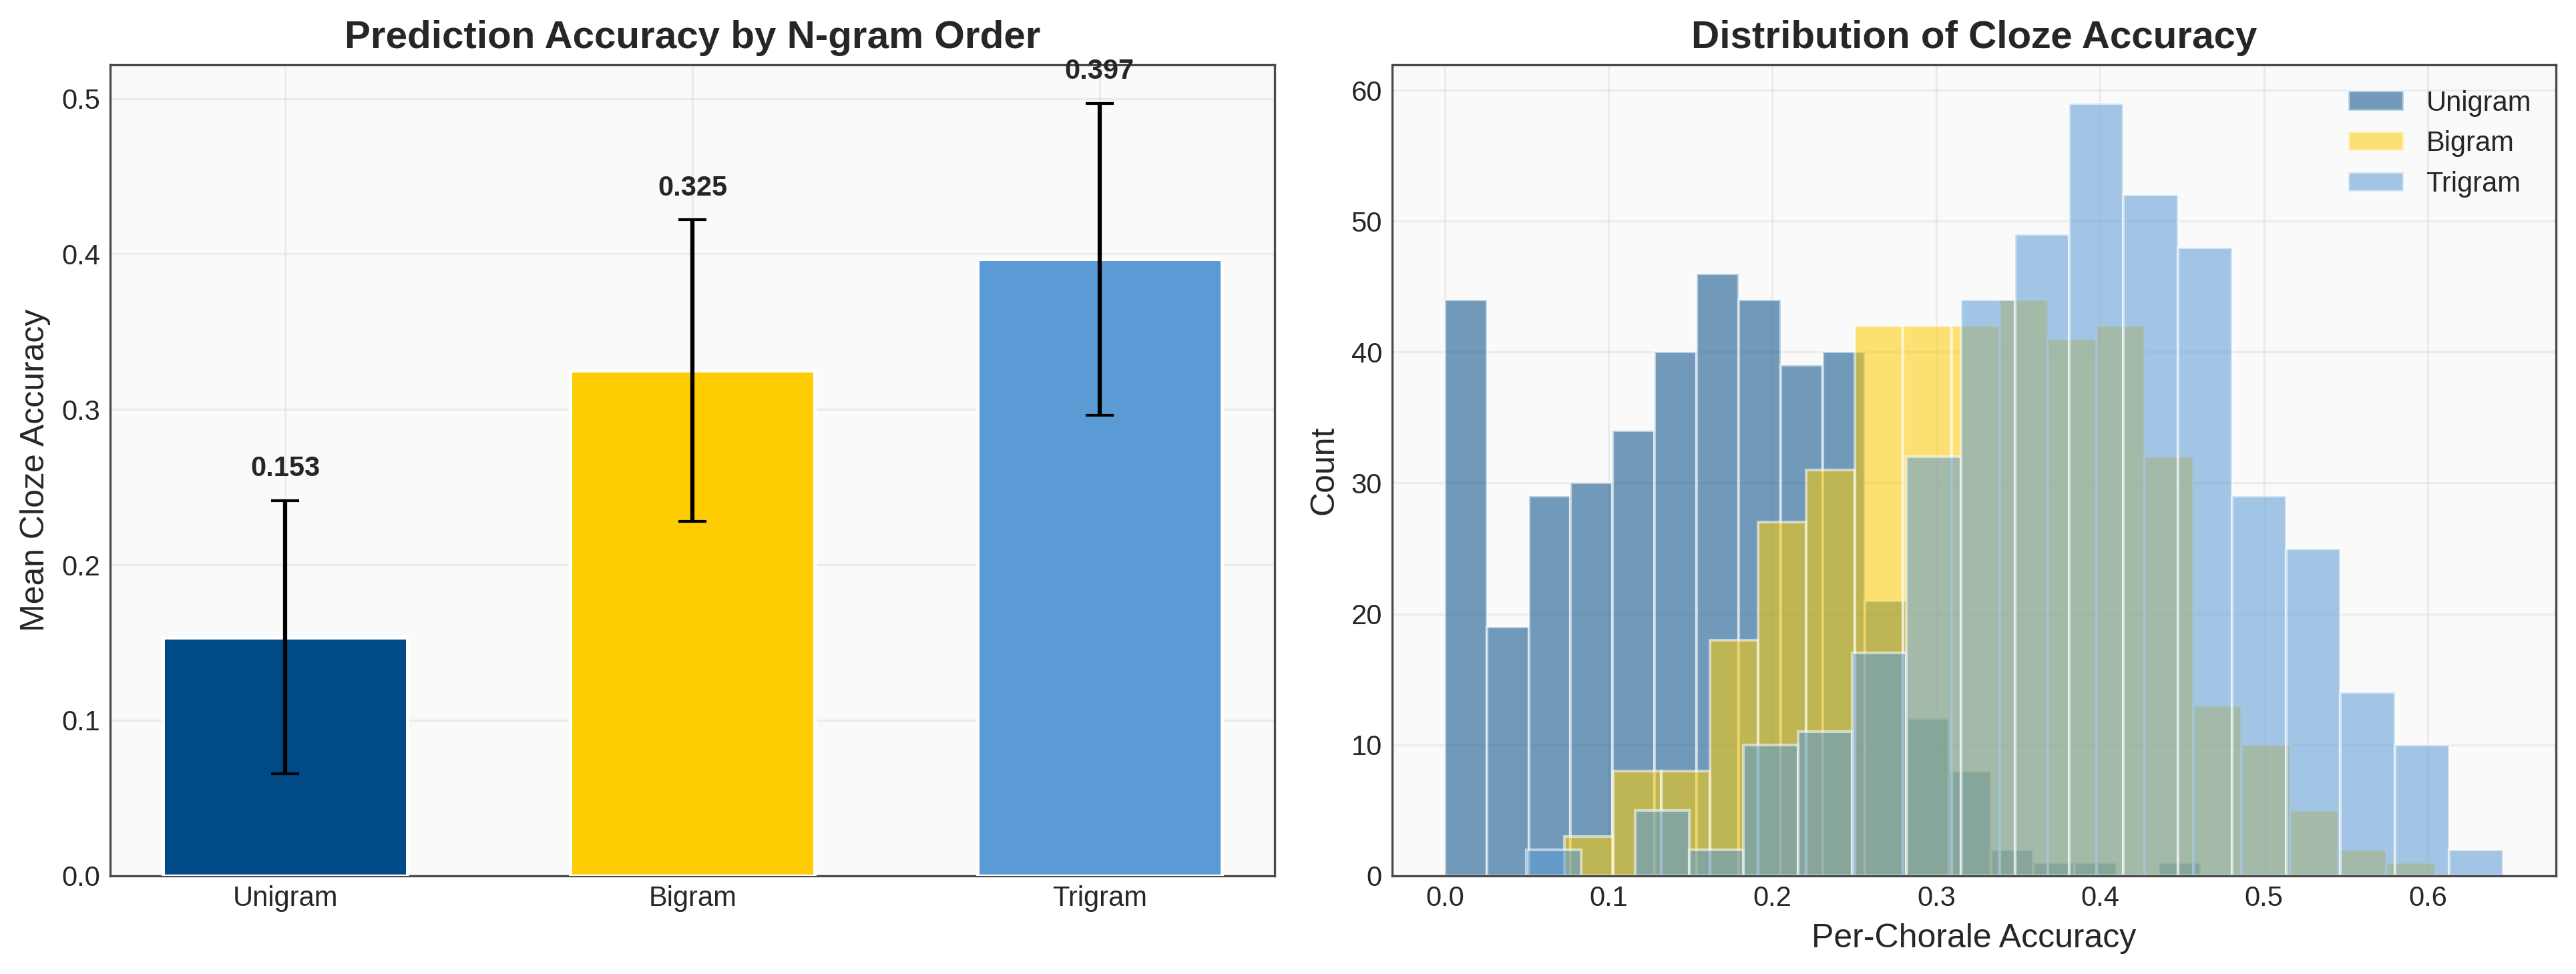

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

labels = ['Unigram', 'Bigram', 'Trigram']
means  = [r['accuracy'].mean() for r in [results_1, results_2, results_3]]
sds    = [r['accuracy'].std()  for r in [results_1, results_2, results_3]]
cols   = [BLUE, GOLD, SKY]

bars = axes[0].bar(labels, means, yerr=sds, color=cols, edgecolor='white',
                    linewidth=1.2, capsize=5, width=0.6, zorder=3)
for bar, m, s in zip(bars, means, sds):
    axes[0].text(bar.get_x() + bar.get_width()/2, m + s + 0.012,
                 f'{m:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Mean Cloze Accuracy')
axes[0].set_title('Prediction Accuracy by N-gram Order')

for res, col, lab in zip([results_1, results_2, results_3], cols, labels):
    axes[1].hist(res['accuracy'], bins=18, alpha=0.55, color=col, label=lab, edgecolor='white')
axes[1].set_xlabel('Per-Chorale Accuracy')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Cloze Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig1_accuracy_by_model_order.png', dpi=300, bbox_inches='tight')
plt.savefig('fig1_accuracy_by_model_order.pdf', bbox_inches='tight')
plt.show()

### Figure 2: Cross-Entropy & Perplexity

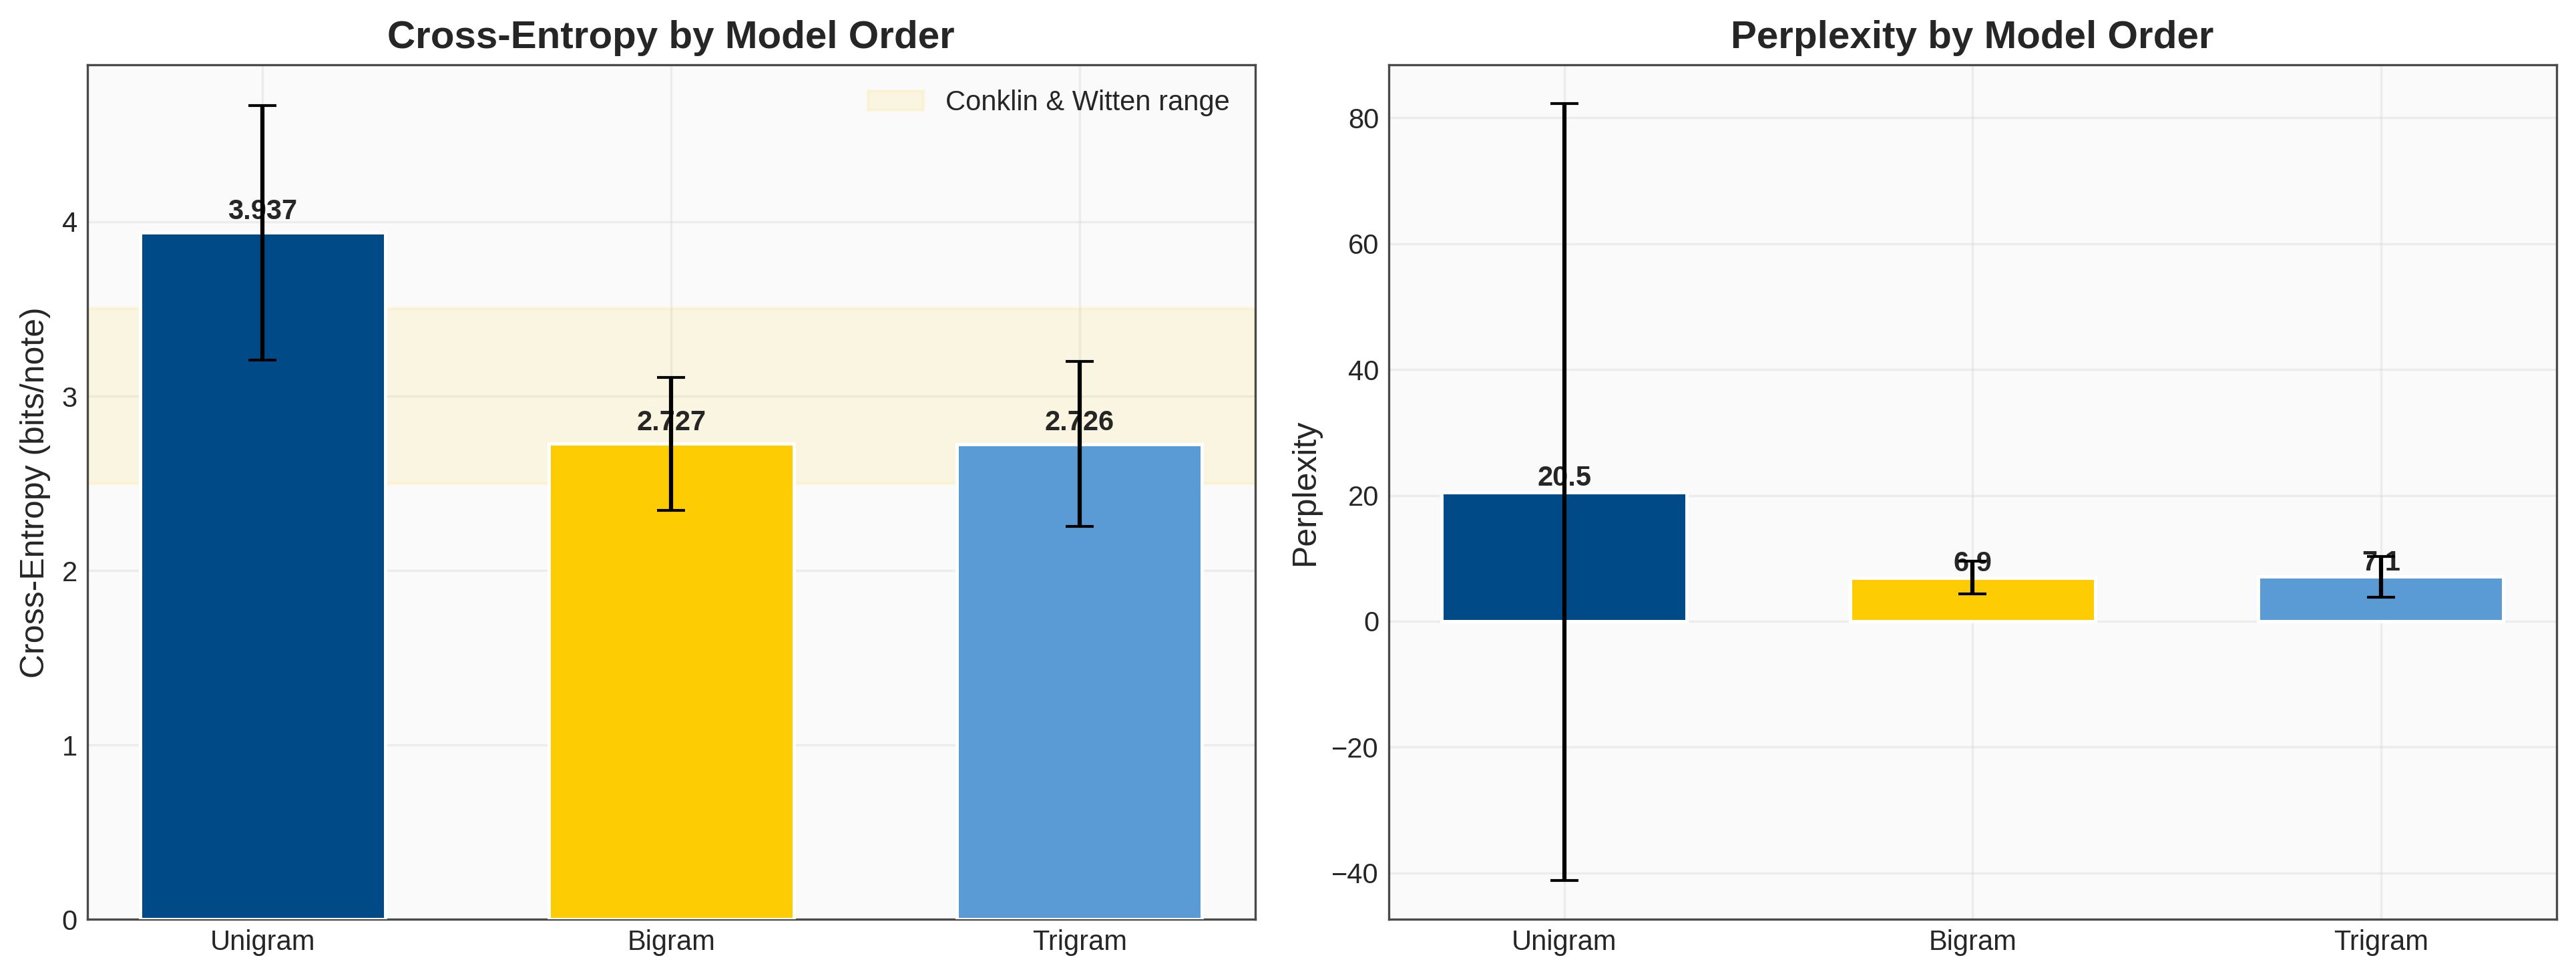

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ce_means = [r['cross_entropy'].mean() for r in [results_1, results_2, results_3]]
ce_sds   = [r['cross_entropy'].std()  for r in [results_1, results_2, results_3]]
pp_means = [r['perplexity'].mean()    for r in [results_1, results_2, results_3]]
pp_sds   = [r['perplexity'].std()     for r in [results_1, results_2, results_3]]

# Cross-entropy
bars1 = axes[0].bar(labels, ce_means, yerr=ce_sds, color=cols, edgecolor='white',
                     linewidth=1.2, capsize=5, width=0.6, zorder=3)
axes[0].axhspan(2.5, 3.5, alpha=0.10, color=GOLD, label='Conklin & Witten range')
for bar, m in zip(bars1, ce_means):
    axes[0].text(bar.get_x() + bar.get_width()/2, m + 0.08,
                 f'{m:.3f}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Cross-Entropy (bits/note)')
axes[0].set_title('Cross-Entropy by Model Order')
axes[0].legend(loc='upper right', framealpha=0.9)

# Perplexity
bars2 = axes[1].bar(labels, pp_means, yerr=pp_sds, color=cols, edgecolor='white',
                     linewidth=1.2, capsize=5, width=0.6, zorder=3)
for bar, m in zip(bars2, pp_means):
    axes[1].text(bar.get_x() + bar.get_width()/2, m + 1,
                 f'{m:.1f}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_ylabel('Perplexity')
axes[1].set_title('Perplexity by Model Order')

plt.tight_layout()
plt.savefig('fig2_crossentropy_perplexity.png', dpi=300, bbox_inches='tight')
plt.savefig('fig2_crossentropy_perplexity.pdf', bbox_inches='tight')
plt.show()

## 7. Experiment 2
Does a chorale's pitch-vocabulary diversity predict how hard it is for the trigram model?

In [46]:
def compute_entropy(melody):
    counts = Counter(melody)
    total  = sum(counts.values())
    return -sum((c / total) * math.log2(c / total) for c in counts.values() if c > 0)

In [47]:
entropy_map = {}
for i, c in enumerate(chorales):
    mel = extract_melody(c, 0)
    if len(mel) >= 10:
        entropy_map[i] = compute_entropy(mel)

matched = results_3[results_3['chorale_id'].isin(entropy_map.keys())].copy()
matched['entropy'] = matched['chorale_id'].map(entropy_map)

entropies = matched['entropy'].values
accs      = matched['accuracy'].values

r_val, p_val   = stats.pearsonr(entropies, accs)
rho_val, p_rho = stats.spearmanr(entropies, accs)

print(f"N = {len(matched)} chorales")
print(f"Pearson  r = {r_val:.4f},  p = {p_val:.4e}")
print(f"Spearman ρ = {rho_val:.4f}, p = {p_rho:.4e}")

N = 411 chorales
Pearson  r = -0.0299,  p = 5.4531e-01
Spearman ρ = -0.0345, p = 4.8517e-01


### Figure 3: Entropy vs. Accuracy

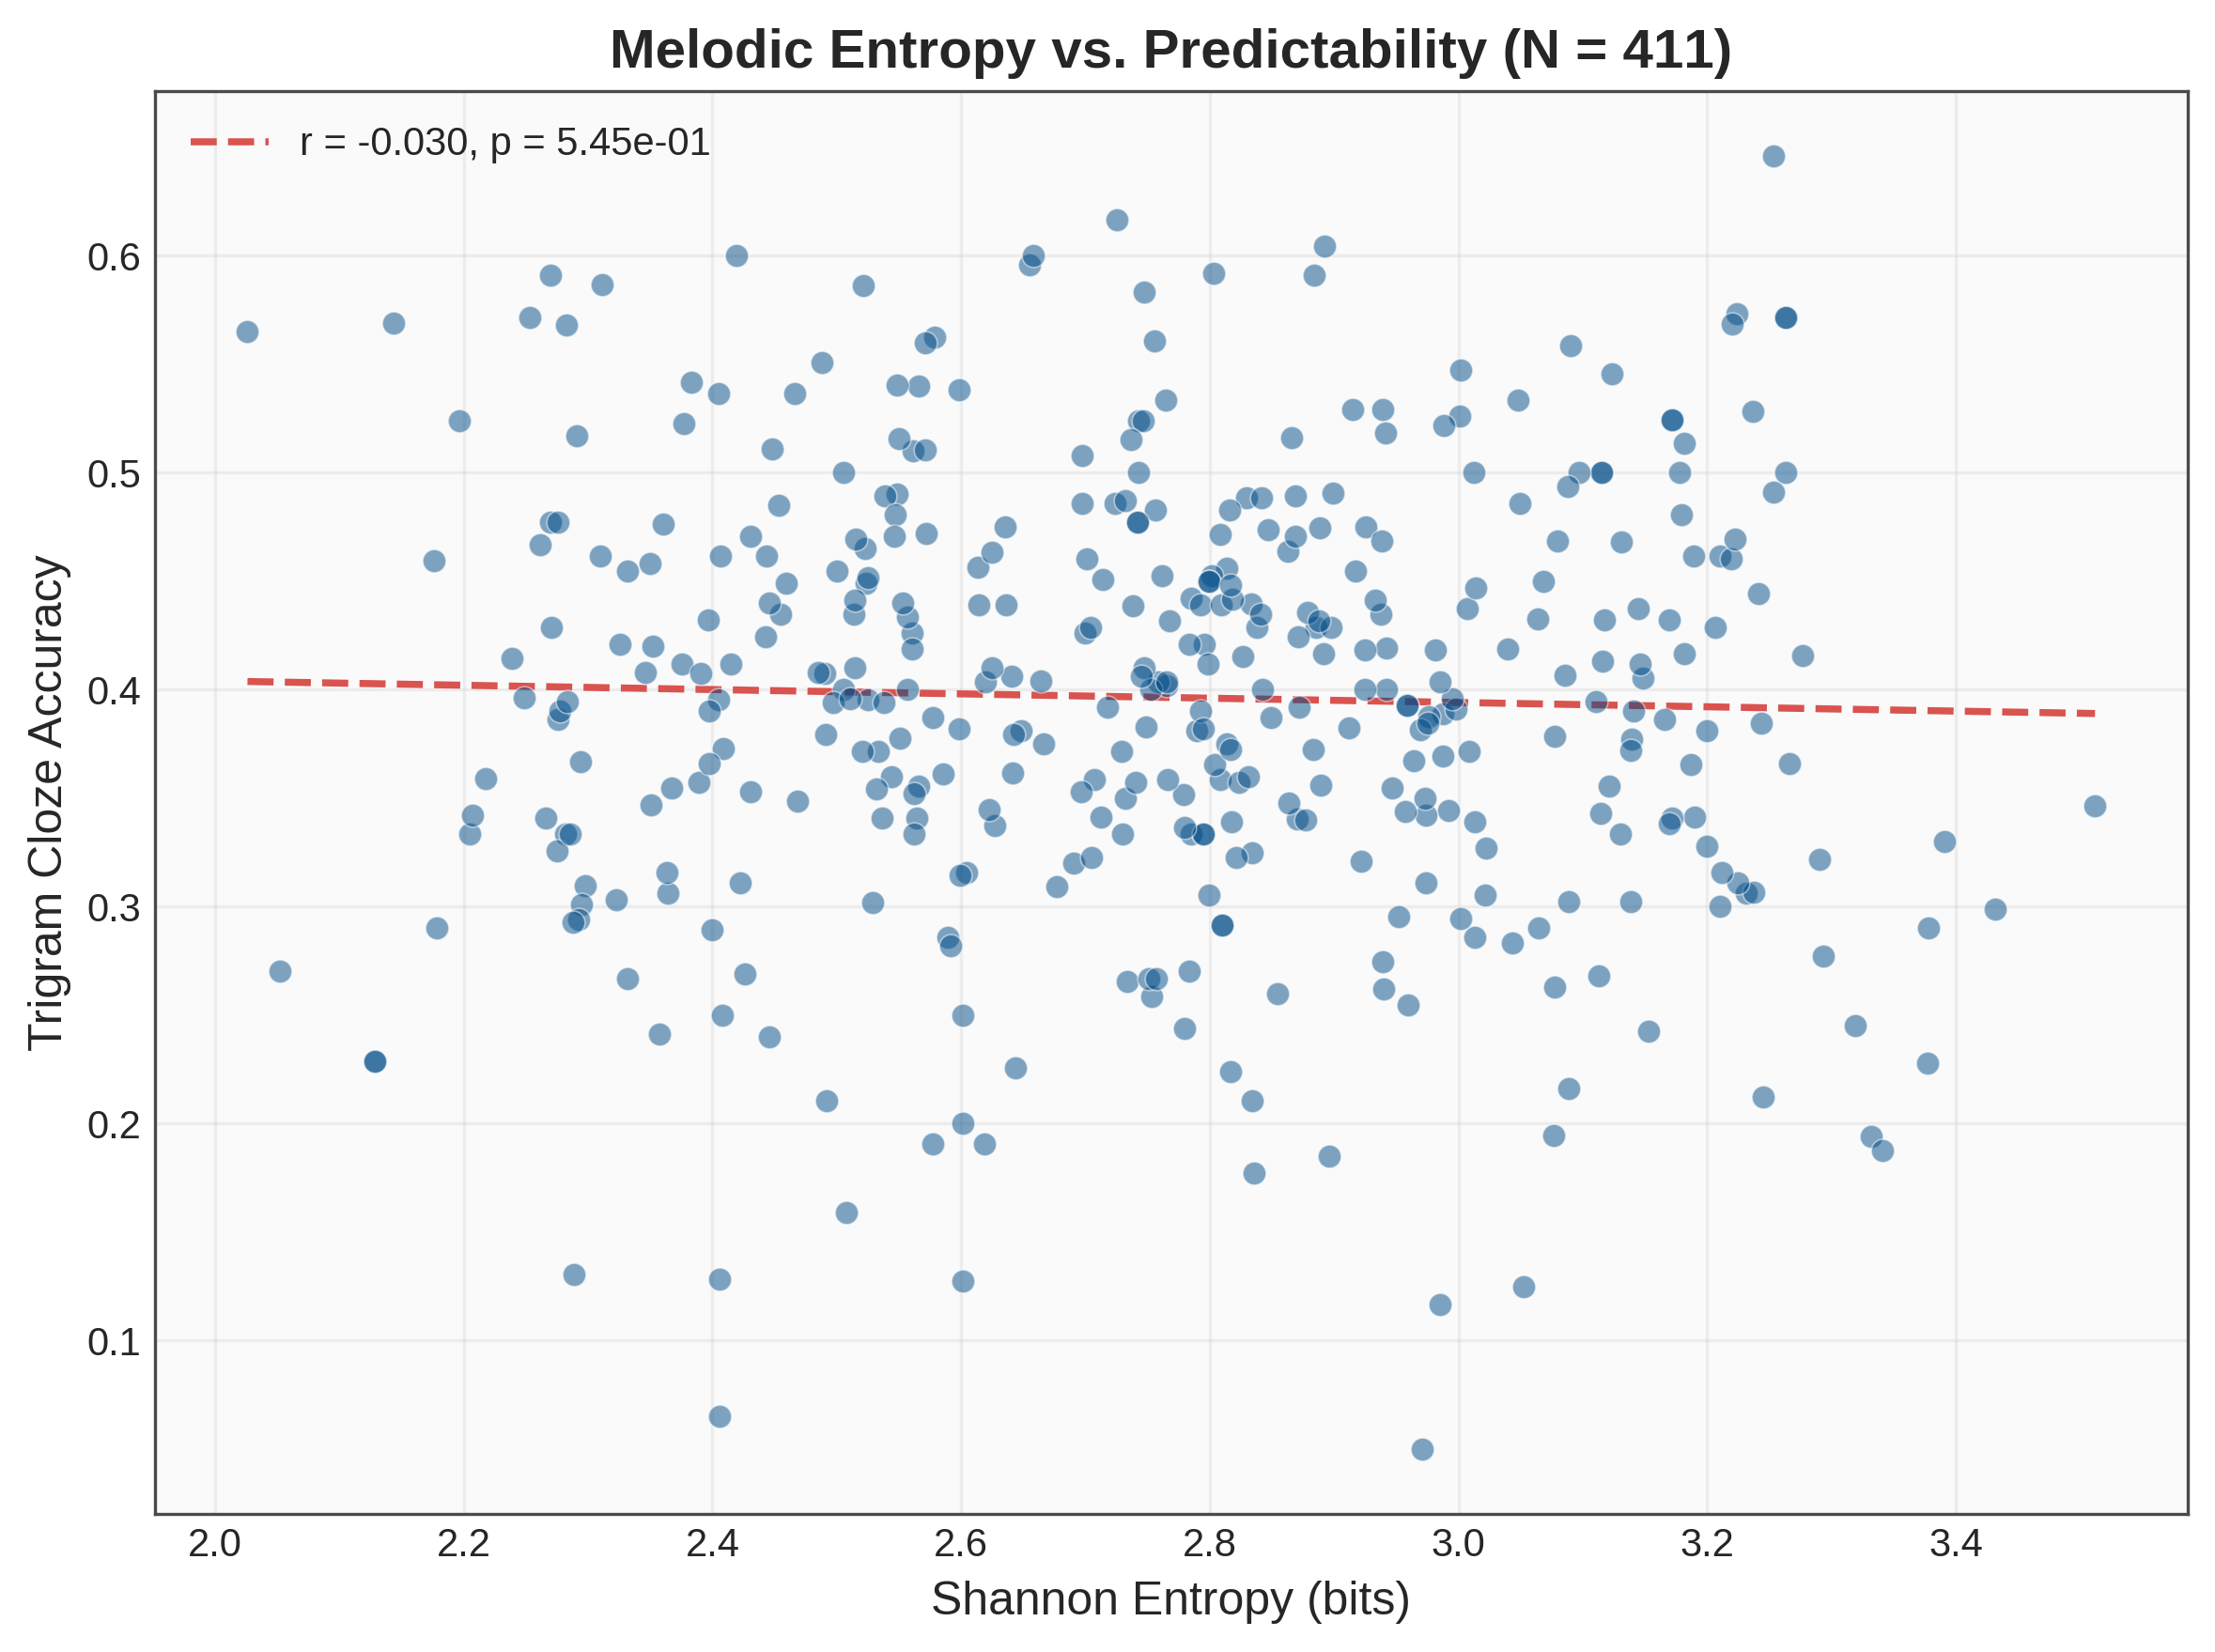

In [48]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(entropies, accs, alpha=0.5, c=BLUE, s=35, edgecolors='white', linewidth=0.4, zorder=3)

z = np.polyfit(entropies, accs, 1)
x_sorted = np.sort(entropies)
ax.plot(x_sorted, np.poly1d(z)(x_sorted), '--', color=CORAL, lw=1.8,
        label=f'r = {r_val:.3f}, p = {p_val:.2e}')

ax.set_xlabel('Shannon Entropy (bits)')
ax.set_ylabel('Trigram Cloze Accuracy')
ax.set_title(f'Melodic Entropy vs. Predictability (N = {len(matched)})')
ax.legend(framealpha=0.9)

plt.tight_layout()
plt.savefig('fig3_entropy_vs_accuracy.png', dpi=300, bbox_inches='tight')
plt.savefig('fig3_entropy_vs_accuracy.pdf', bbox_inches='tight')
plt.show()

## 8. Experiment 3
Are outer voices (soprano, bass) more predictable than inner voices (alto, tenor)?

In [41]:
part_names = ['Soprano', 'Alto', 'Tenor', 'Bass']
part_results = {}

for idx, name in enumerate(part_names):
    print(f"Evaluating {name} (part {idx})")
    part_results[name] = evaluate_cloze(chorales, part_index=idx, n_gram_order=3)
    r = part_results[name]
    print(f"  N = {len(r)}  |  acc = {r['accuracy'].mean():.3f}  |  H = {r['cross_entropy'].mean():.3f}")

Evaluating Soprano (part 0)
  N = 411  |  acc = 0.397  |  H = 2.726
Evaluating Alto (part 1)
  N = 411  |  acc = 0.337  |  H = 2.849
Evaluating Tenor (part 2)
  N = 411  |  acc = 0.358  |  H = 3.027
Evaluating Bass (part 3)
  N = 412  |  acc = 0.402  |  H = 3.243


In [42]:
kw_stat, kw_p = stats.kruskal(*[part_results[n]['accuracy'].dropna().values for n in part_names])
N_total = sum(len(part_results[n]) for n in part_names)
k       = len(part_names)
eps_sq  = (kw_stat - k + 1) / (N_total - k)

print(f"Kruskal-Wallis: H = {kw_stat:.2f}, p = {kw_p:.2e}")
print(f"Effect size (ε²) = {eps_sq:.4f}")

voice_table = pd.DataFrame({
    'Voice': part_names,
    'N': [len(part_results[n]) for n in part_names],
    'Accuracy': [f"{part_results[n]['accuracy'].mean():.3f} ± {part_results[n]['accuracy'].std():.3f}" for n in part_names],
    'Cross-entropy': [f"{part_results[n]['cross_entropy'].mean():.3f}" for n in part_names],
    'Perplexity': [f"{part_results[n]['perplexity'].mean():.1f}" for n in part_names],
})
print("\nTable 2: Trigram prediction by voice part")
print(voice_table.to_string(index=False))

Kruskal-Wallis: H = 157.57, p = 6.13e-34
Effect size (ε²) = 0.0942

Table 2: Trigram prediction by voice part
  Voice   N      Accuracy Cross-entropy Perplexity
Soprano 411 0.397 ± 0.100         2.726        7.1
   Alto 411 0.337 ± 0.081         2.849        7.6
  Tenor 411 0.358 ± 0.086         3.027        8.6
   Bass 412 0.402 ± 0.096         3.243       10.1


### Figure 4: Voice Part Comparison

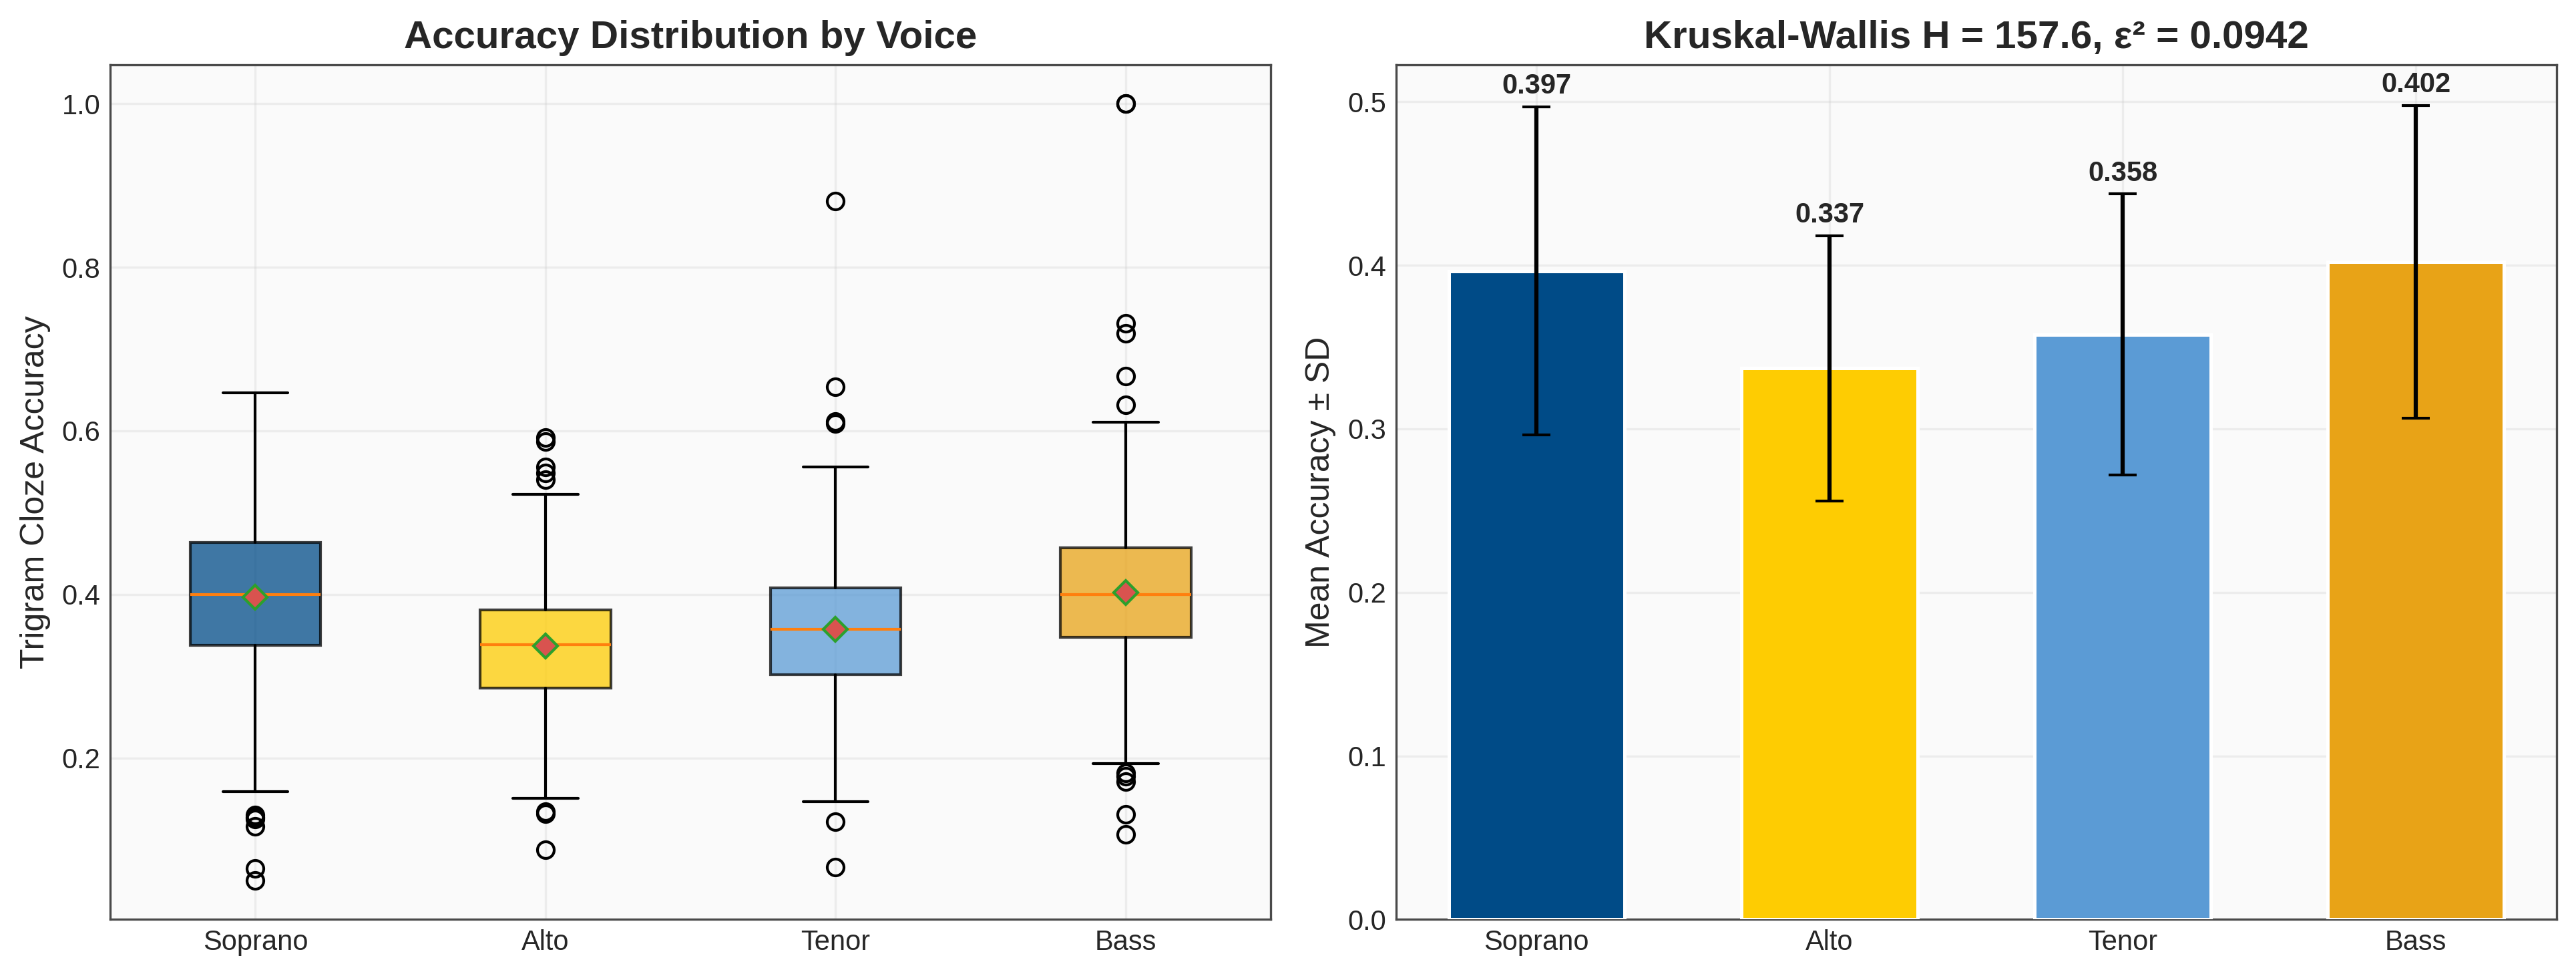

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
voice_cols = [BLUE, GOLD, SKY, AMBER]

# Boxplot
data_box = [part_results[n]['accuracy'].values for n in part_names]
bp = axes[0].boxplot(data_box, tick_labels=part_names, patch_artist=True,
                      showmeans=True, meanprops=dict(marker='D', markerfacecolor=CORAL, markersize=6))
for patch, col in zip(bp['boxes'], voice_cols):
    patch.set_facecolor(col)
    patch.set_alpha(0.75)
axes[0].set_ylabel('Trigram Cloze Accuracy')
axes[0].set_title('Accuracy Distribution by Voice')

# Bar chart with effect-size annotation
m_parts = [part_results[n]['accuracy'].mean() for n in part_names]
s_parts = [part_results[n]['accuracy'].std()  for n in part_names]
bars = axes[1].bar(part_names, m_parts, yerr=s_parts, color=voice_cols, edgecolor='white',
                    linewidth=1.2, capsize=5, width=0.6, zorder=3)
for bar, m, s in zip(bars, m_parts, s_parts):
    axes[1].text(bar.get_x() + bar.get_width()/2, m + s + 0.008,
                 f'{m:.3f}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_ylabel('Mean Accuracy ± SD')
axes[1].set_title(f'Kruskal-Wallis H = {kw_stat:.1f}, ε² = {eps_sq:.4f}')

plt.tight_layout()
plt.savefig('fig4_voice_part_comparison.png', dpi=300, bbox_inches='tight')
plt.savefig('fig4_voice_part_comparison.pdf', bbox_inches='tight')
plt.show()

## 9. Experiment 4
Where in a single melody is the model most "surprised"?

In [51]:
all_melodies = [extract_melody(c, 0) for c in chorales if len(extract_melody(c, 0)) >= 10]
test_idx     = 5
test_melody  = all_melodies[test_idx]
train_mels   = all_melodies[:test_idx] + all_melodies[test_idx + 1:]

model = NgramModel(n=3)
model.train(train_mels)

positions      = list(range(2, len(test_melody)))
note_surprisals = [model.surprisal(tuple(test_melody[j-2:j]), test_melody[j]) for j in positions]
note_names      = [test_melody[j] for j in positions]

print(f"Chorale length: {len(test_melody)} notes  |  Mean surprisal: {np.mean(note_surprisals):.2f} bits")

Chorale length: 46 notes  |  Mean surprisal: 2.07 bits


### Figure 5: Per-Note Surprisal Trace

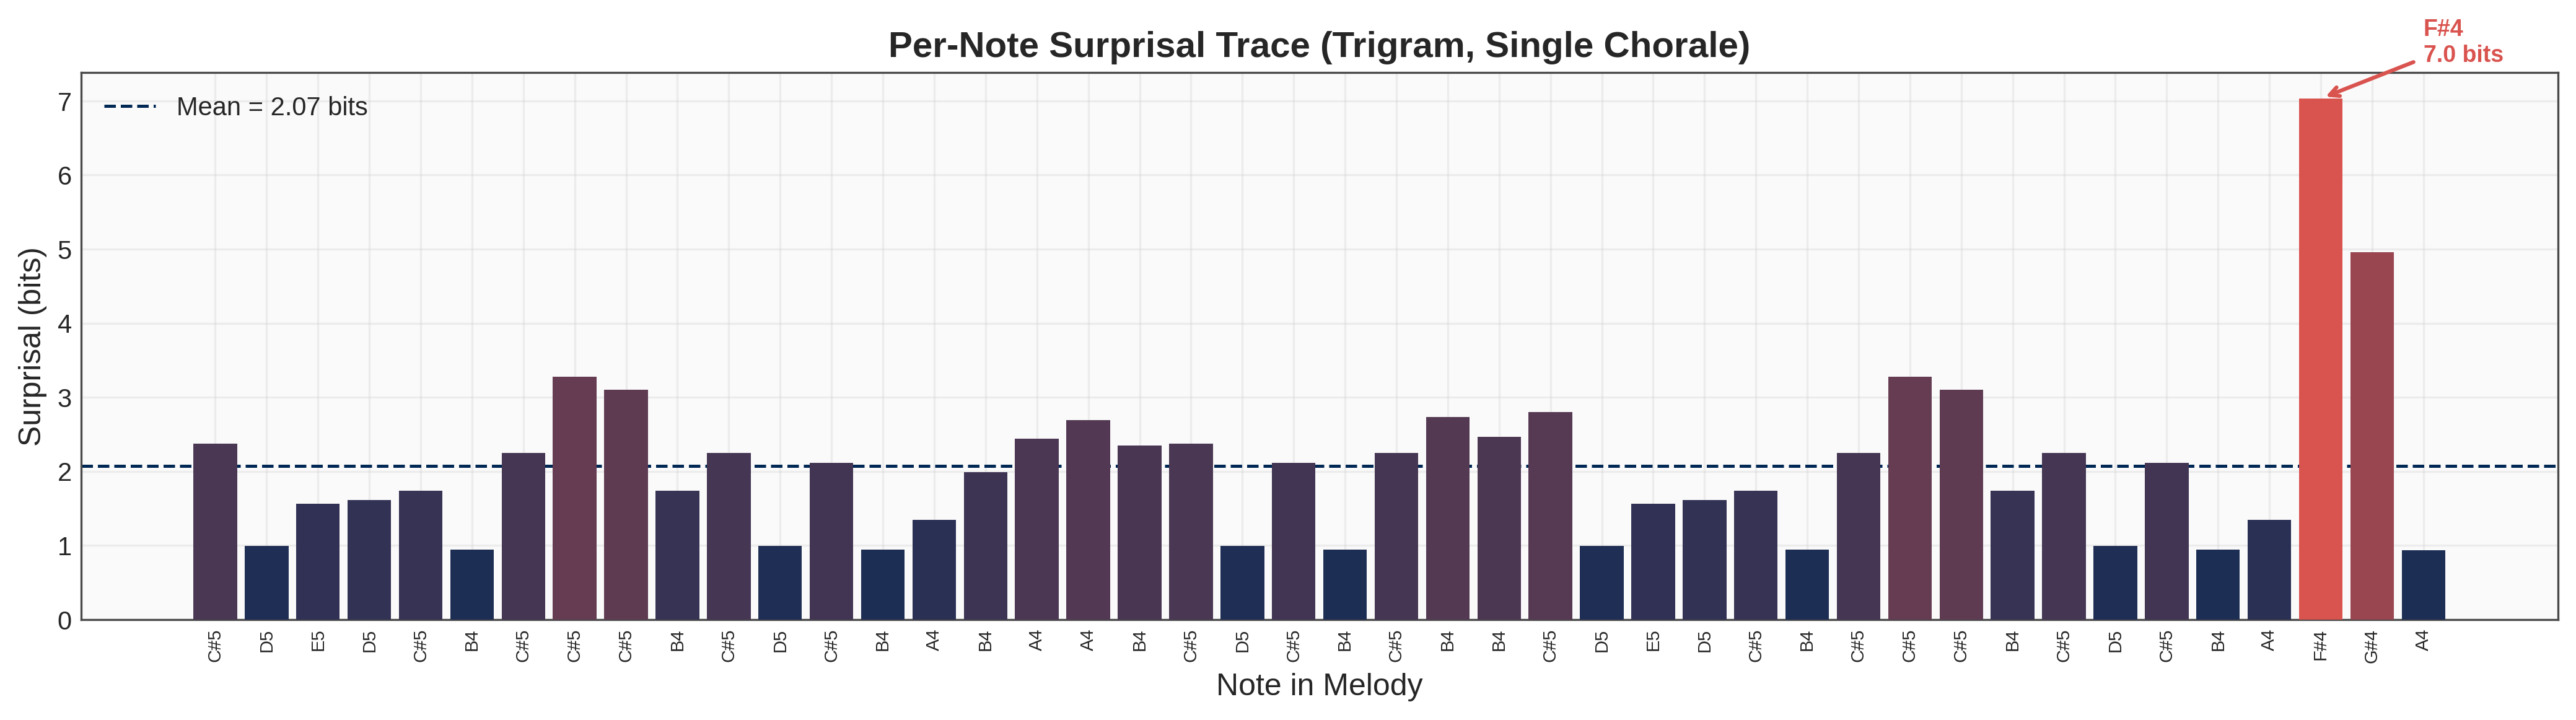

In [59]:
fig, ax = plt.subplots(figsize=(14, 4))
norm_surp = np.array(note_surprisals) / max(note_surprisals)
cmap = plt.cm.RdYlBu_r

cmap_custom = LinearSegmentedColormap.from_list('blue_coral', [NAVY, CORAL])
bar_colors = [cmap_custom(v) for v in norm_surp]
ax.bar(positions, note_surprisals, color=bar_colors, edgecolor='none', width=0.85, zorder=3)
ax.axhline(np.mean(note_surprisals), ls='--', color=NAVY, lw=1.2,
           label=f'Mean = {np.mean(note_surprisals):.2f} bits')

# Peak annotation (we decided to add this to make it more visible the number of bits)
peak = int(np.argmax(note_surprisals))
ax.annotate(f'{note_names[peak]}\n{note_surprisals[peak]:.1f} bits',
            xy=(positions[peak], note_surprisals[peak]),
            xytext=(positions[peak] + 2, note_surprisals[peak] + 0.5),
            arrowprops=dict(arrowstyle='->', color=CORAL, lw=1.5),
            fontsize=9, fontweight='bold', color=CORAL)

ax.set_xticks(positions)
ax.set_xticklabels(note_names, rotation=90, fontsize=7)
ax.set_xlabel('Note in Melody')
ax.set_ylabel('Surprisal (bits)')
ax.set_title('Per-Note Surprisal Trace (Trigram, Single Chorale)')
ax.legend(framealpha=0.9)

plt.tight_layout()
plt.savefig('fig5_surprisal_trace.png', dpi=300, bbox_inches='tight')
plt.savefig('fig5_surprisal_trace.pdf', bbox_inches='tight')
plt.show()

## 10. Experiment 5
Two approaches: the coarse thirds segmentation (original) and a fermata-based segmentation that uses actual musical phrase boundaries.

In [60]:
def surprisal_by_position_thirds(chorales, part_index=0, n_gram_order=3):
    all_mels = [extract_melody(c, part_index) for c in chorales
                if len(extract_melody(c, part_index)) >= 15]
    model = NgramModel(n=n_gram_order)
    model.train(all_mels)

    pos_surp = {'Beginning': [], 'Middle': [], 'End': []}
    for mel in all_mels:
        n = len(mel)
        third = n // 3
        for i in range(n_gram_order - 1, n):
            ctx = tuple(mel[i - n_gram_order + 1:i]) if n_gram_order > 1 else ()
            s   = model.surprisal(ctx, mel[i])
            if   i < third:      pos_surp['Beginning'].append(s)
            elif i < 2 * third:  pos_surp['Middle'].append(s)
            else:                pos_surp['End'].append(s)
    return pos_surp

In [62]:
print("Computing surprisal by thirds")
pos_thirds = surprisal_by_position_thirds(chorales)

for pos in ['Beginning', 'Middle', 'End']:
    v = pos_thirds[pos]
    print(f"  {pos}: mean = {np.mean(v):.3f}, n = {len(v)}")

stat_t, p_t = stats.kruskal(*[pos_thirds[p] for p in ['Beginning', 'Middle', 'End']])
print(f"Kruskal-Wallis (thirds): H = {stat_t:.2f}, p = {p_t:.2e}")

Computing surprisal by thirds
  Beginning: mean = 2.588, n = 6537
  Middle: mean = 2.675, n = 7359
  End: mean = 2.626, n = 7785
Kruskal-Wallis (thirds): H = 24.17, p = 5.64e-06


In [64]:
# Fermata-based segmentation
def surprisal_by_fermata(chorales, part_index=0, n_gram_order=3):
    """Split each chorale at fermatas; classify notes as
       pre-fermata (last 3 before fermata), post-fermata (first 3 after), or mid-phrase."""
    all_mels    = []
    fermata_map = []
    for c in chorales:
        mel = extract_melody(c, part_index)
        if len(mel) < 15:
            continue
        fpos = detect_fermata_positions(c, part_index)
        all_mels.append(mel)
        fermata_map.append(set(fpos))

    model = NgramModel(n=n_gram_order)
    model.train(all_mels)

    surp = {'Pre-fermata': [], 'Post-fermata': [], 'Mid-phrase': []}

    for mel, fset in zip(all_mels, fermata_map):
        # Build zones: 3 notes before each fermata = pre; 3 notes after = post
        pre_indices  = set()
        post_indices = set()
        for fp in fset:
            for offset in range(1, 4):
                if fp - offset >= 0:
                    pre_indices.add(fp - offset)
                if fp + offset < len(mel):
                    post_indices.add(fp + offset)
            pre_indices.add(fp)  # The fermata note itself is "arrival"

        for i in range(n_gram_order - 1, len(mel)):
            ctx = tuple(mel[i - n_gram_order + 1:i]) if n_gram_order > 1 else ()
            s   = model.surprisal(ctx, mel[i])
            if   i in pre_indices:  surp['Pre-fermata'].append(s)
            elif i in post_indices: surp['Post-fermata'].append(s)
            else:                   surp['Mid-phrase'].append(s)

    return surp

In [65]:
print("Computing fermata-based surprisal …")
pos_fermata = surprisal_by_fermata(chorales)

for pos in ['Pre-fermata', 'Post-fermata', 'Mid-phrase']:
    v = pos_fermata[pos]
    print(f"  {pos}: mean = {np.mean(v):.3f}, n = {len(v)}")

stat_f, p_f = stats.kruskal(*[pos_fermata[p] for p in ['Pre-fermata', 'Post-fermata', 'Mid-phrase']])
print(f"Kruskal-Wallis (fermata): H = {stat_f:.2f}, p = {p_f:.2e}")

Computing fermata-based surprisal …
  Pre-fermata: mean = 2.387, n = 9770
  Post-fermata: mean = 3.058, n = 5502
  Mid-phrase: mean = 2.639, n = 6409
Kruskal-Wallis (fermata): H = 1007.06, p = 2.09e-219


### Figure 6: Surprisal by Phrase Position (Thirds + Fermata)

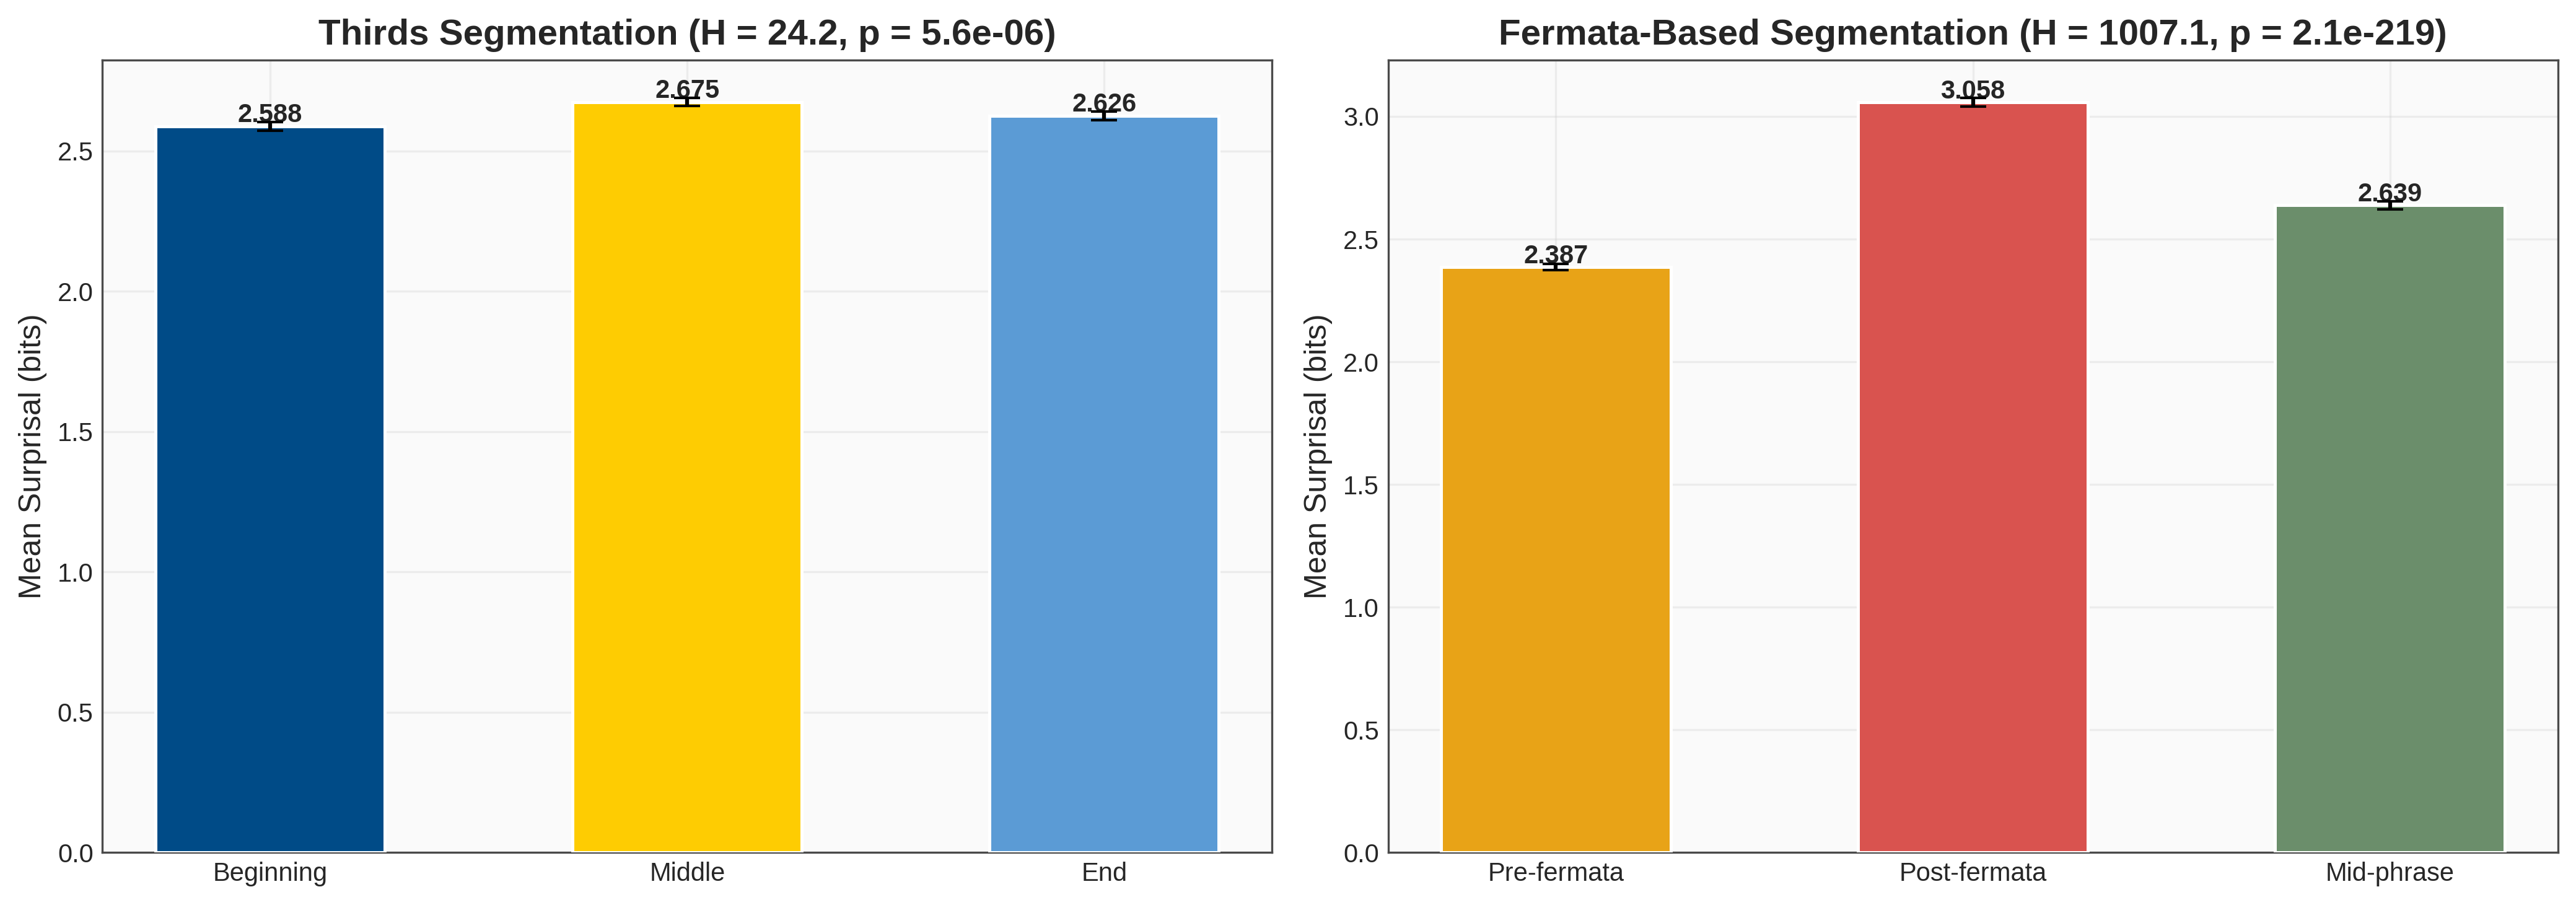

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: thirds
positions_list = ['Beginning', 'Middle', 'End']
means_t = [np.mean(pos_thirds[p]) for p in positions_list]
sems_t  = [stats.sem(pos_thirds[p]) for p in positions_list]
bars_t = axes[0].bar(positions_list, means_t, yerr=sems_t, color=[BLUE, GOLD, SKY],
                      edgecolor='white', linewidth=1.2, capsize=5, width=0.55, zorder=3)
for bar, m in zip(bars_t, means_t):
    axes[0].text(bar.get_x() + bar.get_width()/2, m + 0.015,
                 f'{m:.3f}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Mean Surprisal (bits)')
axes[0].set_title(f'Thirds Segmentation (H = {stat_t:.1f}, p = {p_t:.1e})')

# Right: fermata
ferm_labels = ['Pre-fermata', 'Post-fermata', 'Mid-phrase']
means_f = [np.mean(pos_fermata[p]) for p in ferm_labels]
sems_f  = [stats.sem(pos_fermata[p]) for p in ferm_labels]
bars_f = axes[1].bar(ferm_labels, means_f, yerr=sems_f, color=[AMBER, CORAL, SAGE],
                      edgecolor='white', linewidth=1.2, capsize=5, width=0.55, zorder=3)
for bar, m in zip(bars_f, means_f):
    axes[1].text(bar.get_x() + bar.get_width()/2, m + 0.015,
                 f'{m:.3f}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_ylabel('Mean Surprisal (bits)')
axes[1].set_title(f'Fermata-Based Segmentation (H = {stat_f:.1f}, p = {p_f:.1e})')

plt.tight_layout()
plt.savefig('fig6_surprisal_by_position.png', dpi=300, bbox_inches='tight')
plt.savefig('fig6_surprisal_by_position.pdf', bbox_inches='tight')
plt.show()

## 11. Experiment 6


In [67]:
all_pc = [extract_pitch_classes(c, 0) for c in chorales
          if len(extract_pitch_classes(c, 0)) >= 10]

trans = defaultdict(Counter)
for mel in all_pc:
    for i in range(len(mel) - 1):
        trans[mel[i]][mel[i + 1]] += 1

pc_freq = Counter(pc for mel in all_pc for pc in mel)
top_pcs = [pc for pc, _ in pc_freq.most_common(12)]

matrix = np.zeros((len(top_pcs), len(top_pcs)))
for i, src in enumerate(top_pcs):
    total = sum(trans[src].values())
    if total:
        for j, dst in enumerate(top_pcs):
            matrix[i][j] = trans[src][dst] / total

print(f"Transition matrix: {len(all_pc)} chorales, {len(top_pcs)} pitch classes")

Transition matrix: 411 chorales, 12 pitch classes


### Figure 7: Pitch-Class Transition Heatmap

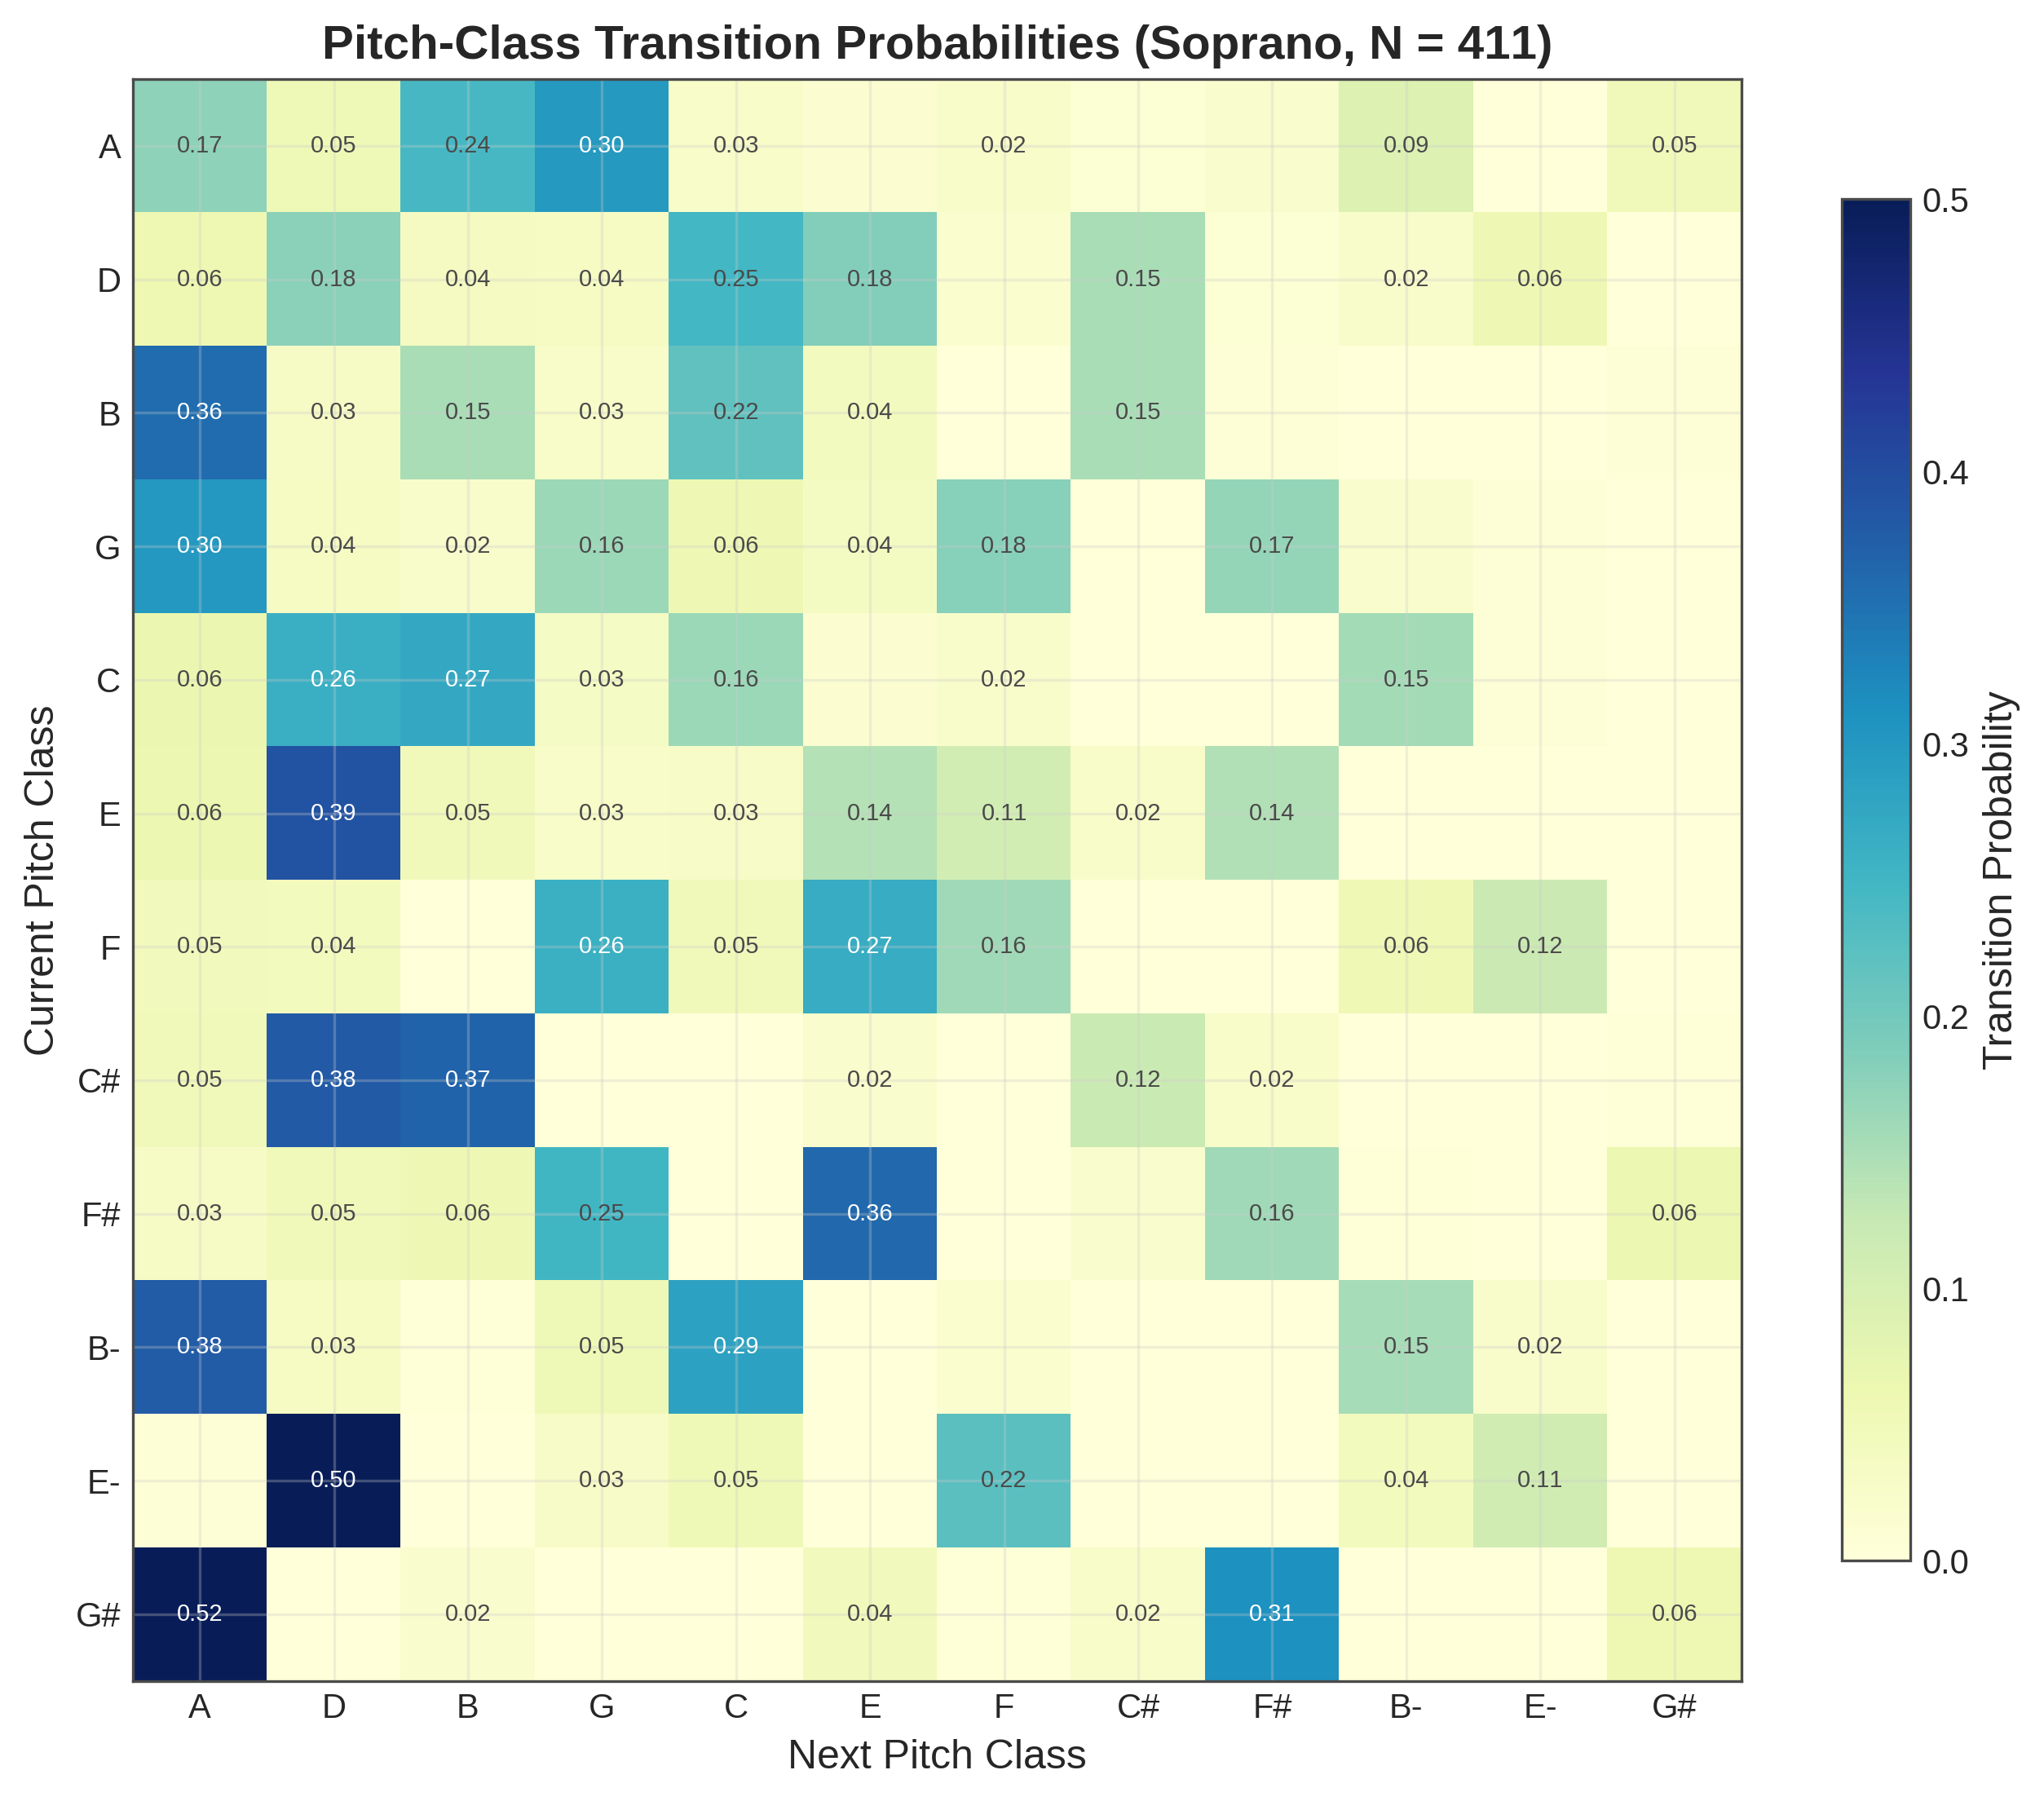

In [68]:
fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(matrix, cmap='YlGnBu', aspect='auto', vmin=0, vmax=0.5)
ax.set_xticks(range(len(top_pcs)))
ax.set_yticks(range(len(top_pcs)))
ax.set_xticklabels(top_pcs, fontsize=10)
ax.set_yticklabels(top_pcs, fontsize=10)
ax.set_xlabel('Next Pitch Class')
ax.set_ylabel('Current Pitch Class')
ax.set_title(f'Pitch-Class Transition Probabilities (Soprano, N = {len(all_pc)})')

for i in range(len(top_pcs)):
    for j in range(len(top_pcs)):
        v = matrix[i][j]
        if v > 0.02:
            colour = 'white' if v > 0.25 else SLATE
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7, color=colour)

plt.colorbar(im, ax=ax, label='Transition Probability', shrink=0.85)
plt.tight_layout()
plt.savefig('fig7_transition_matrix.png', dpi=300, bbox_inches='tight')
plt.savefig('fig7_transition_matrix.pdf', bbox_inches='tight')
plt.show()

## 12. Experiment 7

In [69]:
all_intervals = []
for c in chorales:
    all_intervals.extend(extract_intervals(c, 0))

stepwise     = sum(1 for iv in all_intervals if abs(iv) <= 2)
stepwise_pct = 100.0 * stepwise / len(all_intervals)
print(f"Total intervals: {len(all_intervals)}")
print(f"Stepwise (≤ 2 semitones): {stepwise_pct:.1f}%")

Total intervals: 22098
Stepwise (≤ 2 semitones): 84.3%


### Figure 8: Interval Distribution

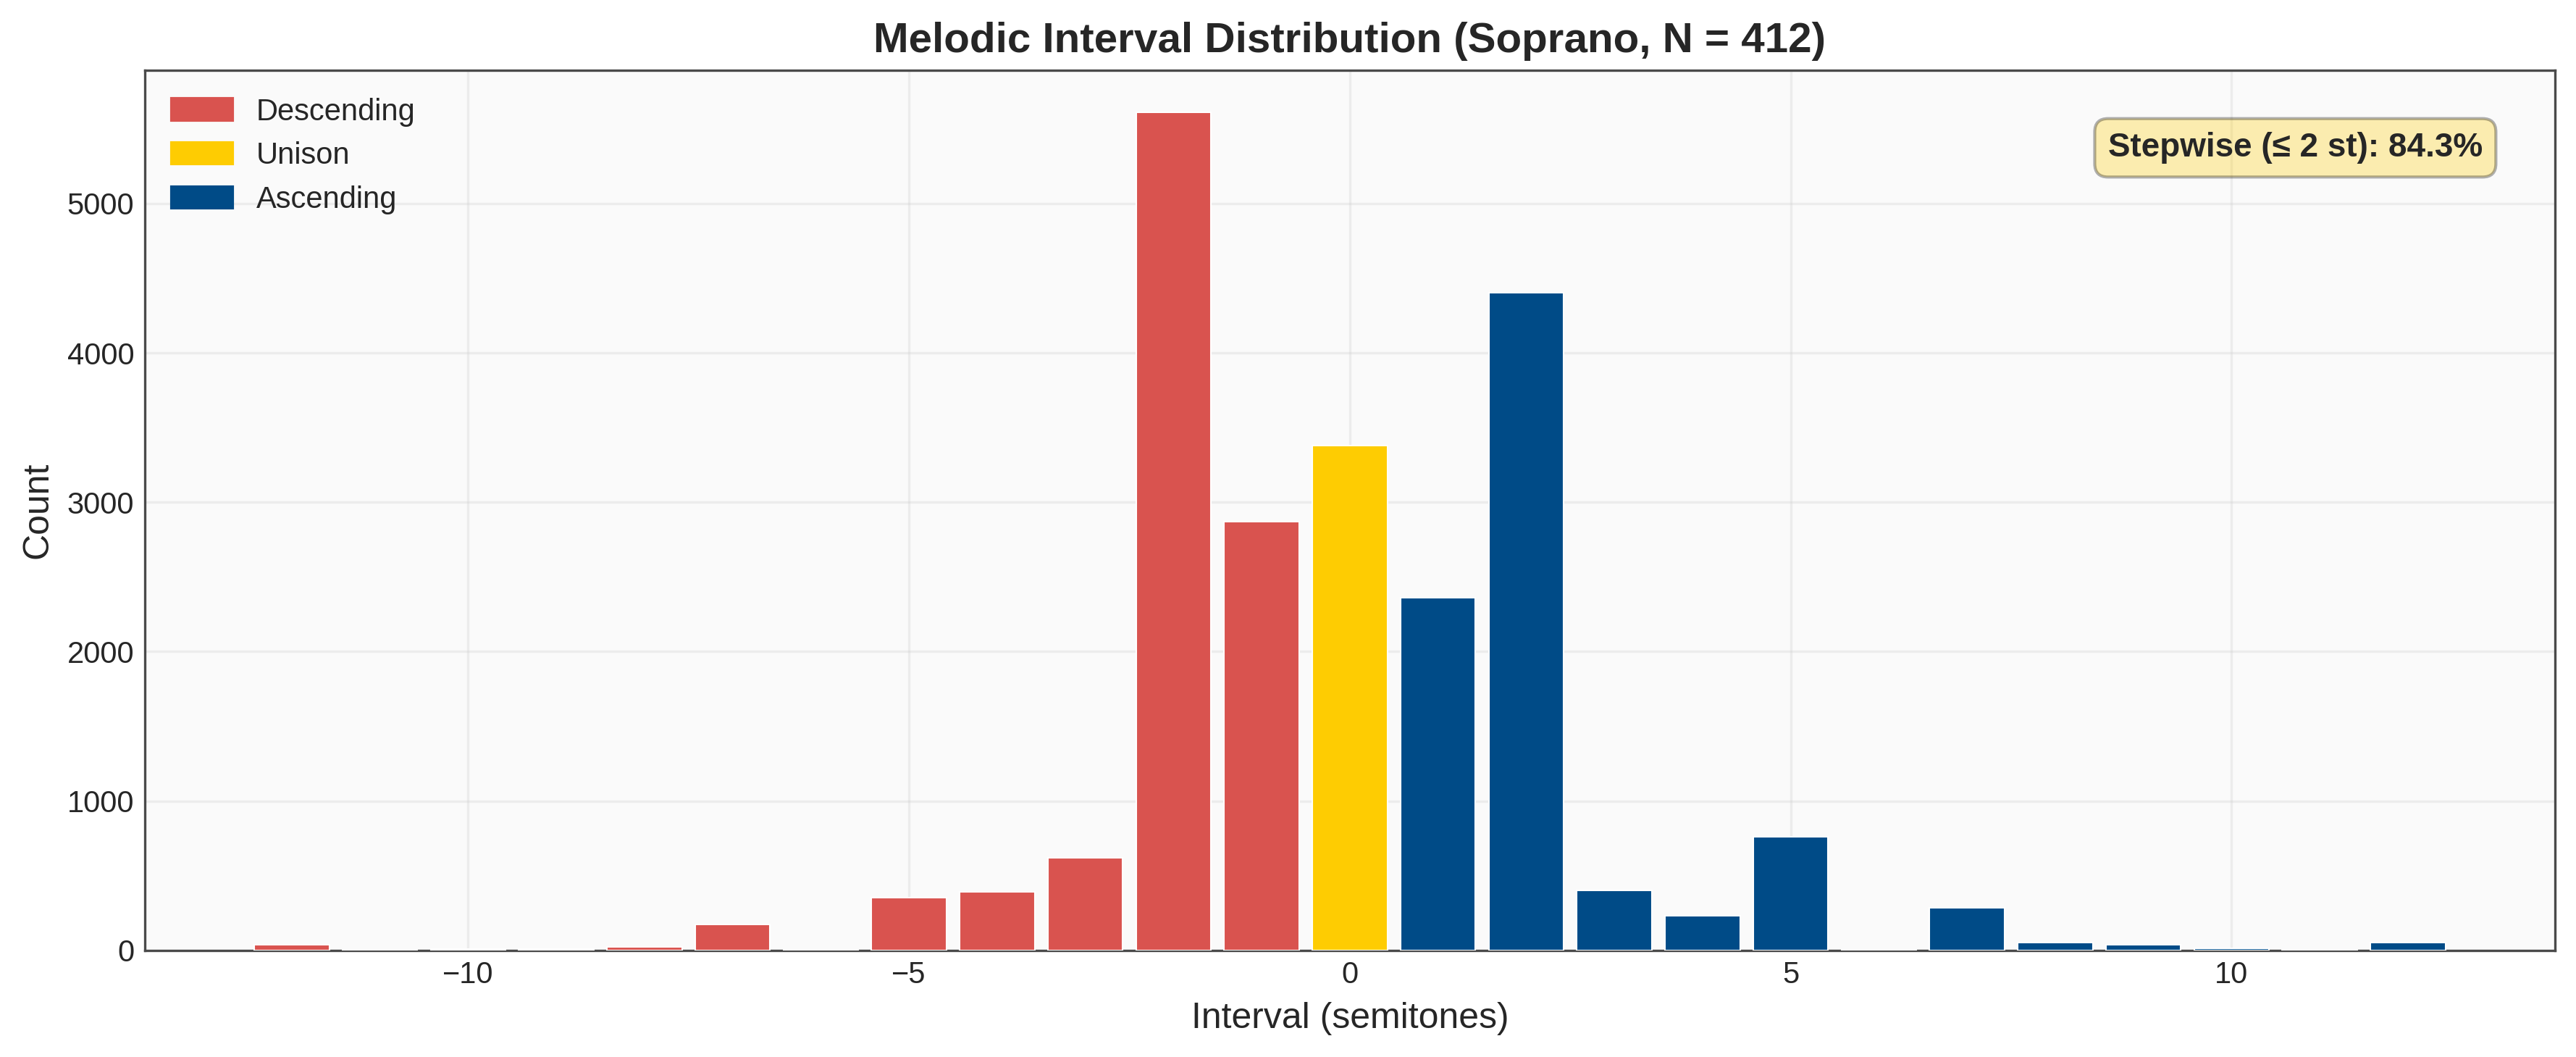

In [70]:
iv_range  = list(range(-12, 13))
iv_counts = [sum(1 for iv in all_intervals if iv == x and -12 <= iv <= 12) for x in iv_range]

fig, ax = plt.subplots(figsize=(12, 5))
bar_cols = [CORAL if x < 0 else (GOLD if x == 0 else BLUE) for x in iv_range]
ax.bar(iv_range, iv_counts, color=bar_cols, edgecolor='white', linewidth=0.5, width=0.85, zorder=3)
ax.set_xlabel('Interval (semitones)')
ax.set_ylabel('Count')
ax.set_title(f'Melodic Interval Distribution (Soprano, N = {len(chorales)})')
ax.text(0.97, 0.93, f'Stepwise (≤ 2 st): {stepwise_pct:.1f}%',
        transform=ax.transAxes, ha='right', va='top', fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor=GOLD, alpha=0.3))

# Legend patches
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=CORAL, label='Descending'),
                    Patch(color=GOLD,  label='Unison'),
                    Patch(color=BLUE,  label='Ascending')],
          loc='upper left', framealpha=0.9)

plt.tight_layout()
plt.savefig('fig8_interval_distribution.png', dpi=300, bbox_inches='tight')
plt.savefig('fig8_interval_distribution.pdf', bbox_inches='tight')
plt.show()

## 13. Extension A
Does the accuracy–cross-entropy dissociation shrink with interpolated smoothing?

In [71]:
class InterpolatedNgramModel:
    """Trigram model with deleted interpolation (λ weights)."""

    def __init__(self, lam=(0.1, 0.3, 0.6)):
        self.lam = lam  # (unigram, bigram, trigram)
        self.uni = NgramModel(n=1)
        self.bi  = NgramModel(n=2)
        self.tri = NgramModel(n=3)

    def train(self, sequences):
        self.uni.train(sequences)
        self.bi.train(sequences)
        self.tri.train(sequences)

    def probability(self, ctx2, target):
        ctx1 = ctx2[-1:] if len(ctx2) >= 1 else ()
        p_uni = self.uni.probability((), target)
        p_bi  = self.bi.probability(ctx1, target)
        p_tri = self.tri.probability(ctx2, target)
        return self.lam[0] * p_uni + self.lam[1] * p_bi + self.lam[2] * p_tri

    def surprisal(self, ctx2, target):
        return -math.log2(max(self.probability(ctx2, target), 1e-20))

    def predict(self, ctx2):
        # argmax over vocabulary
        best, best_p = None, -1
        for tok in self.tri.vocabulary:
            p = self.probability(ctx2, tok)
            if p > best_p:
                best, best_p = tok, p
        return best


def evaluate_interpolated(chorales, part_index=0, min_melody_len=10, lam=(0.1, 0.3, 0.6)):
    all_mels = []
    for c in chorales:
        mel = extract_melody(c, part_index)
        if len(mel) >= min_melody_len:
            all_mels.append(mel)

    model   = InterpolatedNgramModel(lam=lam)
    results = []

    for idx, test in enumerate(all_mels):
        train = all_mels[:idx] + all_mels[idx + 1:]
        model.train(train)
        correct, total = 0, 0
        surprisals = []
        for j in range(2, len(test)):
            ctx = tuple(test[j-2:j])
            pred = model.predict(ctx)
            if pred == test[j]:
                correct += 1
            total += 1
            surprisals.append(model.surprisal(ctx, test[j]))
        if total:
            acc = correct / total
            ce  = np.mean(surprisals)
            results.append({'accuracy': acc, 'cross_entropy': ce, 'perplexity': 2**ce})
    return pd.DataFrame(results)

In [73]:
# This process can be long, add comments if needed
print("Running interpolated trigram (λ = 0.1, 0.3, 0.6)")
results_interp = evaluate_interpolated(chorales)
print(f"  N = {len(results_interp)}")
print(f"  Accuracy:      {results_interp['accuracy'].mean():.3f} ± {results_interp['accuracy'].std():.3f}")
print(f"  Cross-entropy: {results_interp['cross_entropy'].mean():.3f}")
print(f"  Perplexity:    {results_interp['perplexity'].mean():.1f}")

print(f"\nComparison:")
print(f"  Laplace trigram: acc = {results_3['accuracy'].mean():.3f}, H = {results_3['cross_entropy'].mean():.3f}")
print(f"  Interpolated: acc = {results_interp['accuracy'].mean():.3f}, H = {results_interp['cross_entropy'].mean():.3f}")

Running interpolated trigram (λ = 0.1, 0.3, 0.6)
  N = 411
  Accuracy:      0.396 ± 0.103
  Cross-entropy: 2.716
  Perplexity:    6.9

Comparison:
  Laplace trigram: acc = 0.397, H = 2.726
  Interpolated: acc = 0.396, H = 2.716


## 14. Extension B
Do longer chorales give the model more context to learn from?

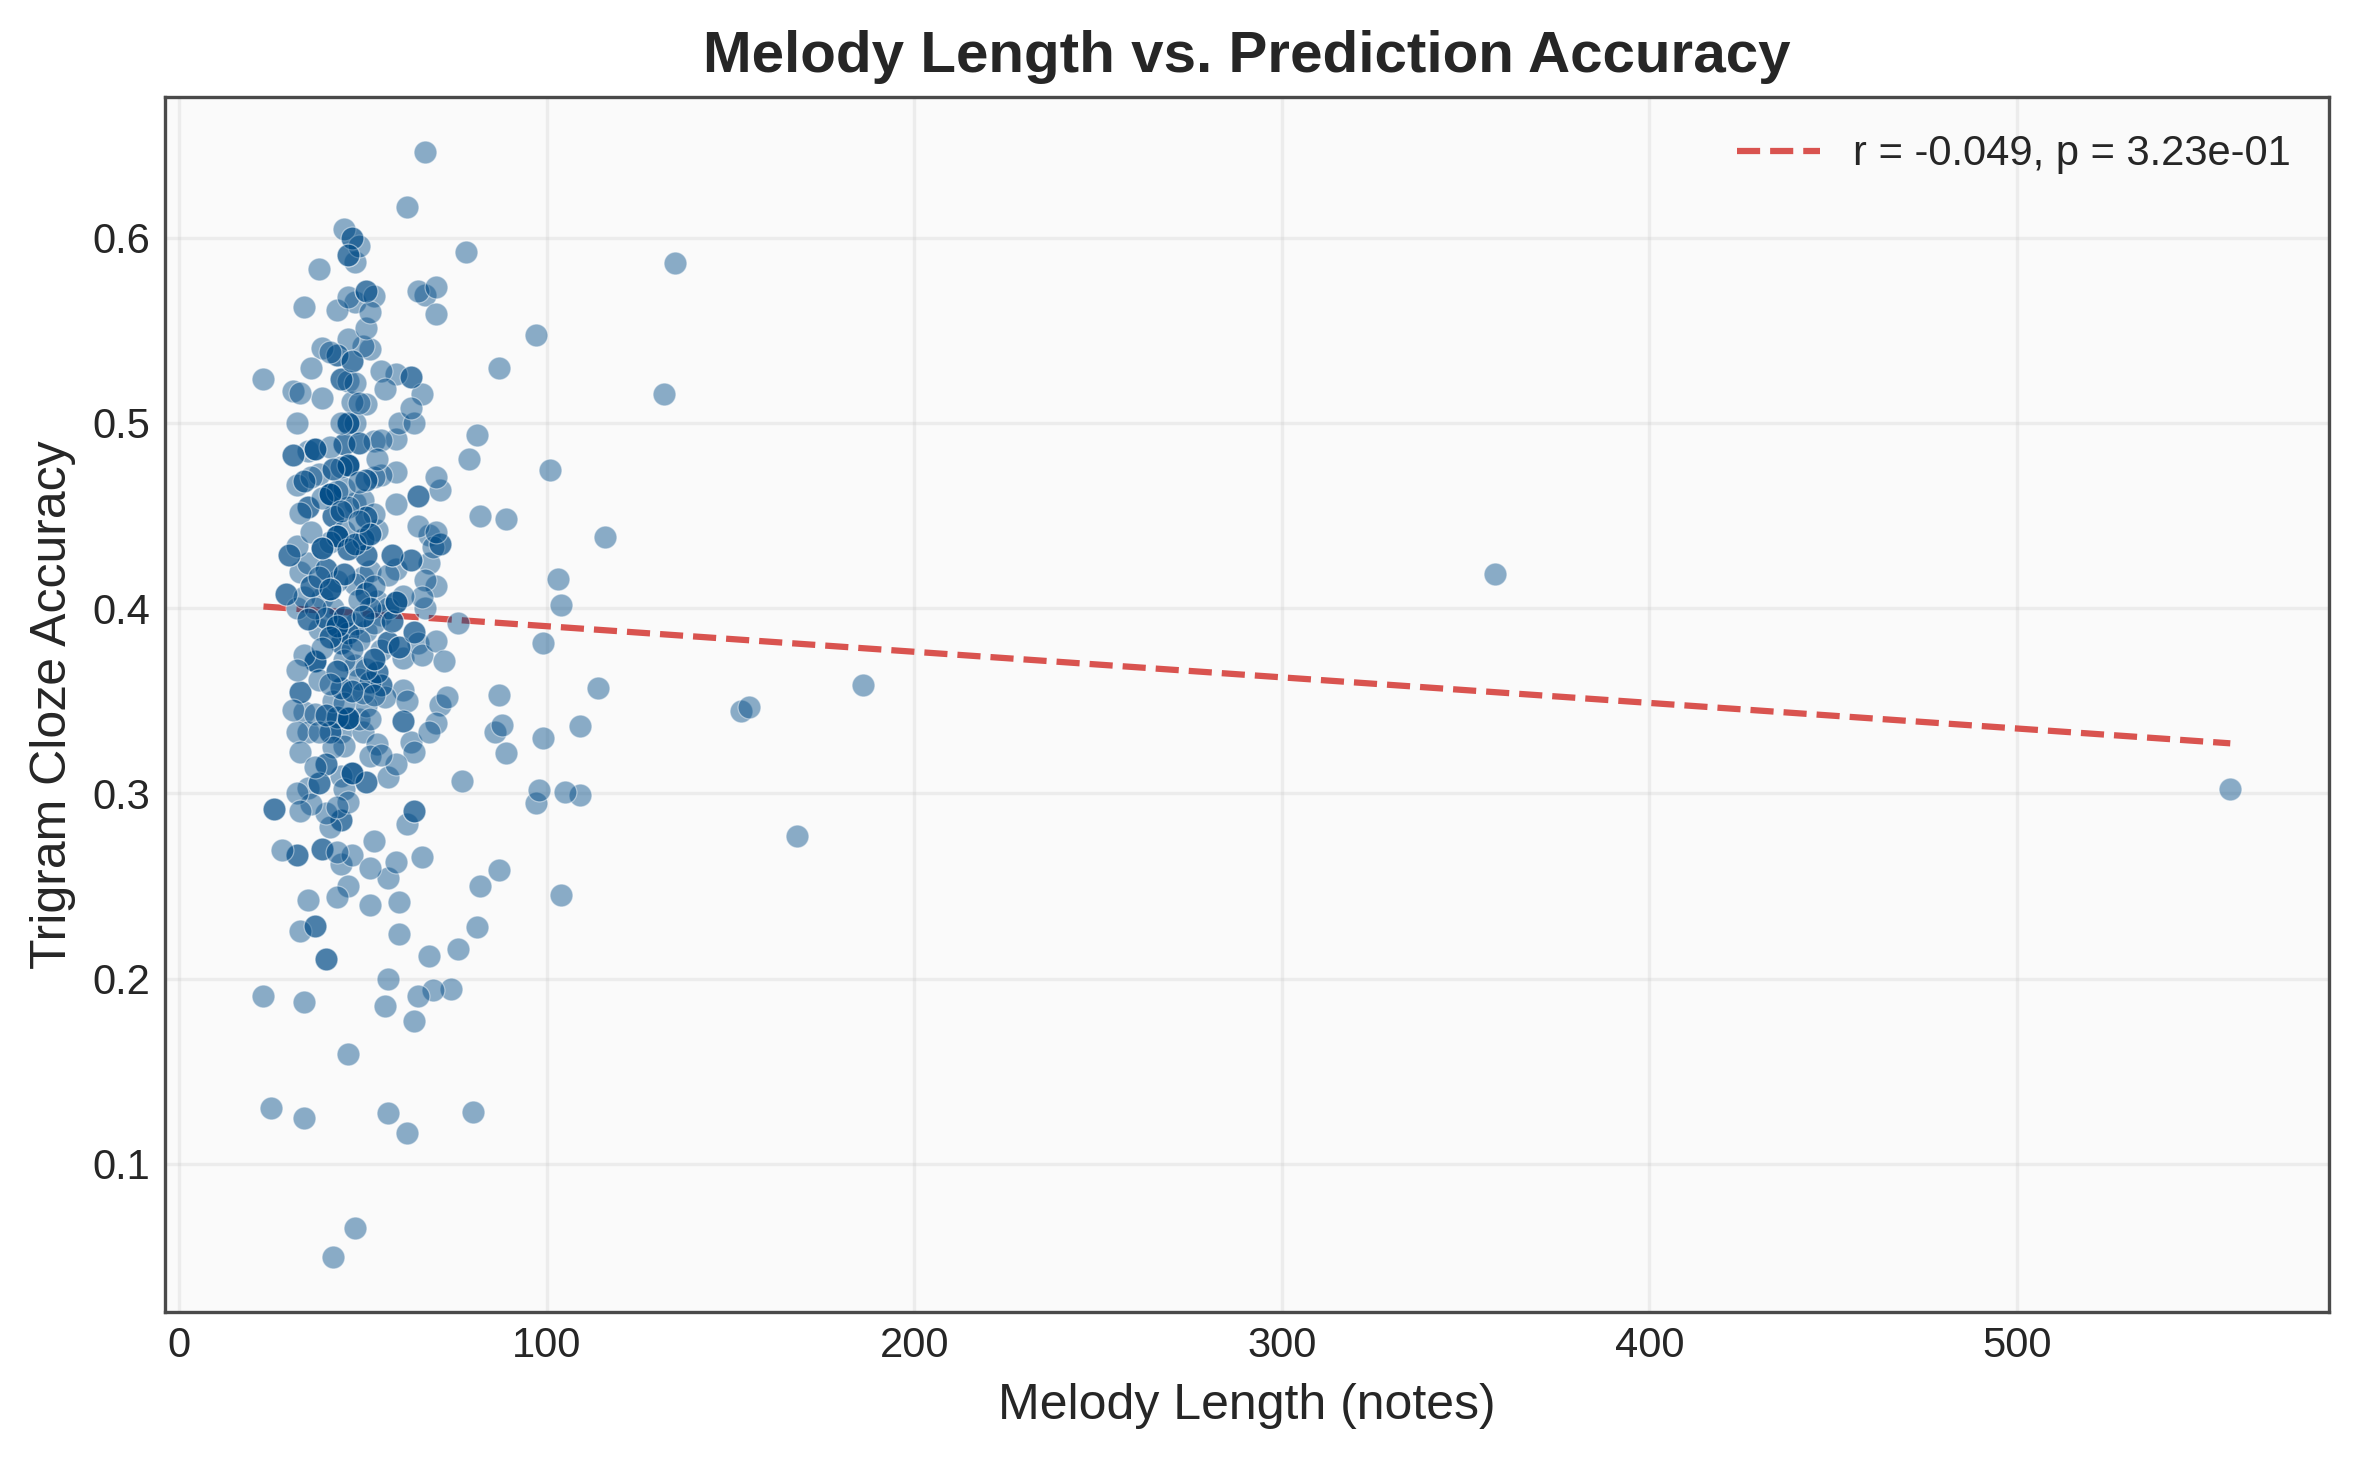

Pearson r = -0.0488, p = 3.2344e-01


In [74]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(results_3['melody_length'], results_3['accuracy'],
           alpha=0.45, c=BLUE, s=30, edgecolors='white', linewidth=0.3, zorder=3)

r_len, p_len = stats.pearsonr(results_3['melody_length'], results_3['accuracy'])
z = np.polyfit(results_3['melody_length'], results_3['accuracy'], 1)
x_s = np.sort(results_3['melody_length'].values)
ax.plot(x_s, np.poly1d(z)(x_s), '--', color=CORAL, lw=1.5,
        label=f'r = {r_len:.3f}, p = {p_len:.2e}')

ax.set_xlabel('Melody Length (notes)')
ax.set_ylabel('Trigram Cloze Accuracy')
ax.set_title('Melody Length vs. Prediction Accuracy')
ax.legend(framealpha=0.9)

plt.tight_layout()
plt.savefig('fig9_length_vs_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Pearson r = {r_len:.4f}, p = {p_len:.4e}")

## 15. Extension C
How often is the correct note in the model's top 3 or top 5 guesses?

In [75]:
def evaluate_topk(chorales, part_index=0, n_gram_order=3, k_values=(1, 3, 5), min_len=10):
    all_mels = [extract_melody(c, part_index) for c in chorales
                if len(extract_melody(c, part_index)) >= min_len]
    model = NgramModel(n=n_gram_order)
    topk_correct = {k: 0 for k in k_values}
    total = 0

    for idx, test in enumerate(all_mels):
        train = all_mels[:idx] + all_mels[idx + 1:]
        model.train(train)
        for j in range(n_gram_order - 1, len(test)):
            ctx = tuple(test[j - n_gram_order + 1:j]) if n_gram_order > 1 else ()
            true = test[j]
            # Get top-k predictions
            if ctx in model.counts:
                ranked = [tok for tok, _ in model.counts[ctx].most_common(max(k_values))]
            else:
                ranked = []
            for k in k_values:
                if true in ranked[:k]:
                    topk_correct[k] += 1
            total += 1

    return {k: topk_correct[k] / total for k in k_values}, total

In [78]:
print("Computing top-k accuracy:")
topk_accs, topk_total = evaluate_topk(chorales)
for k, acc in topk_accs.items():
    print(f"  Top-{k}: {acc:.3f}  ({acc*100:.1f}%)")
print(f"  Total predictions: {topk_total}")

Computing top-k accuracy:
  Top-1: 0.393  (39.3%)
  Top-3: 0.750  (75.0%)
  Top-5: 0.890  (89.0%)
  Total predictions: 21681


### Figure 10: Top-k Accuracy

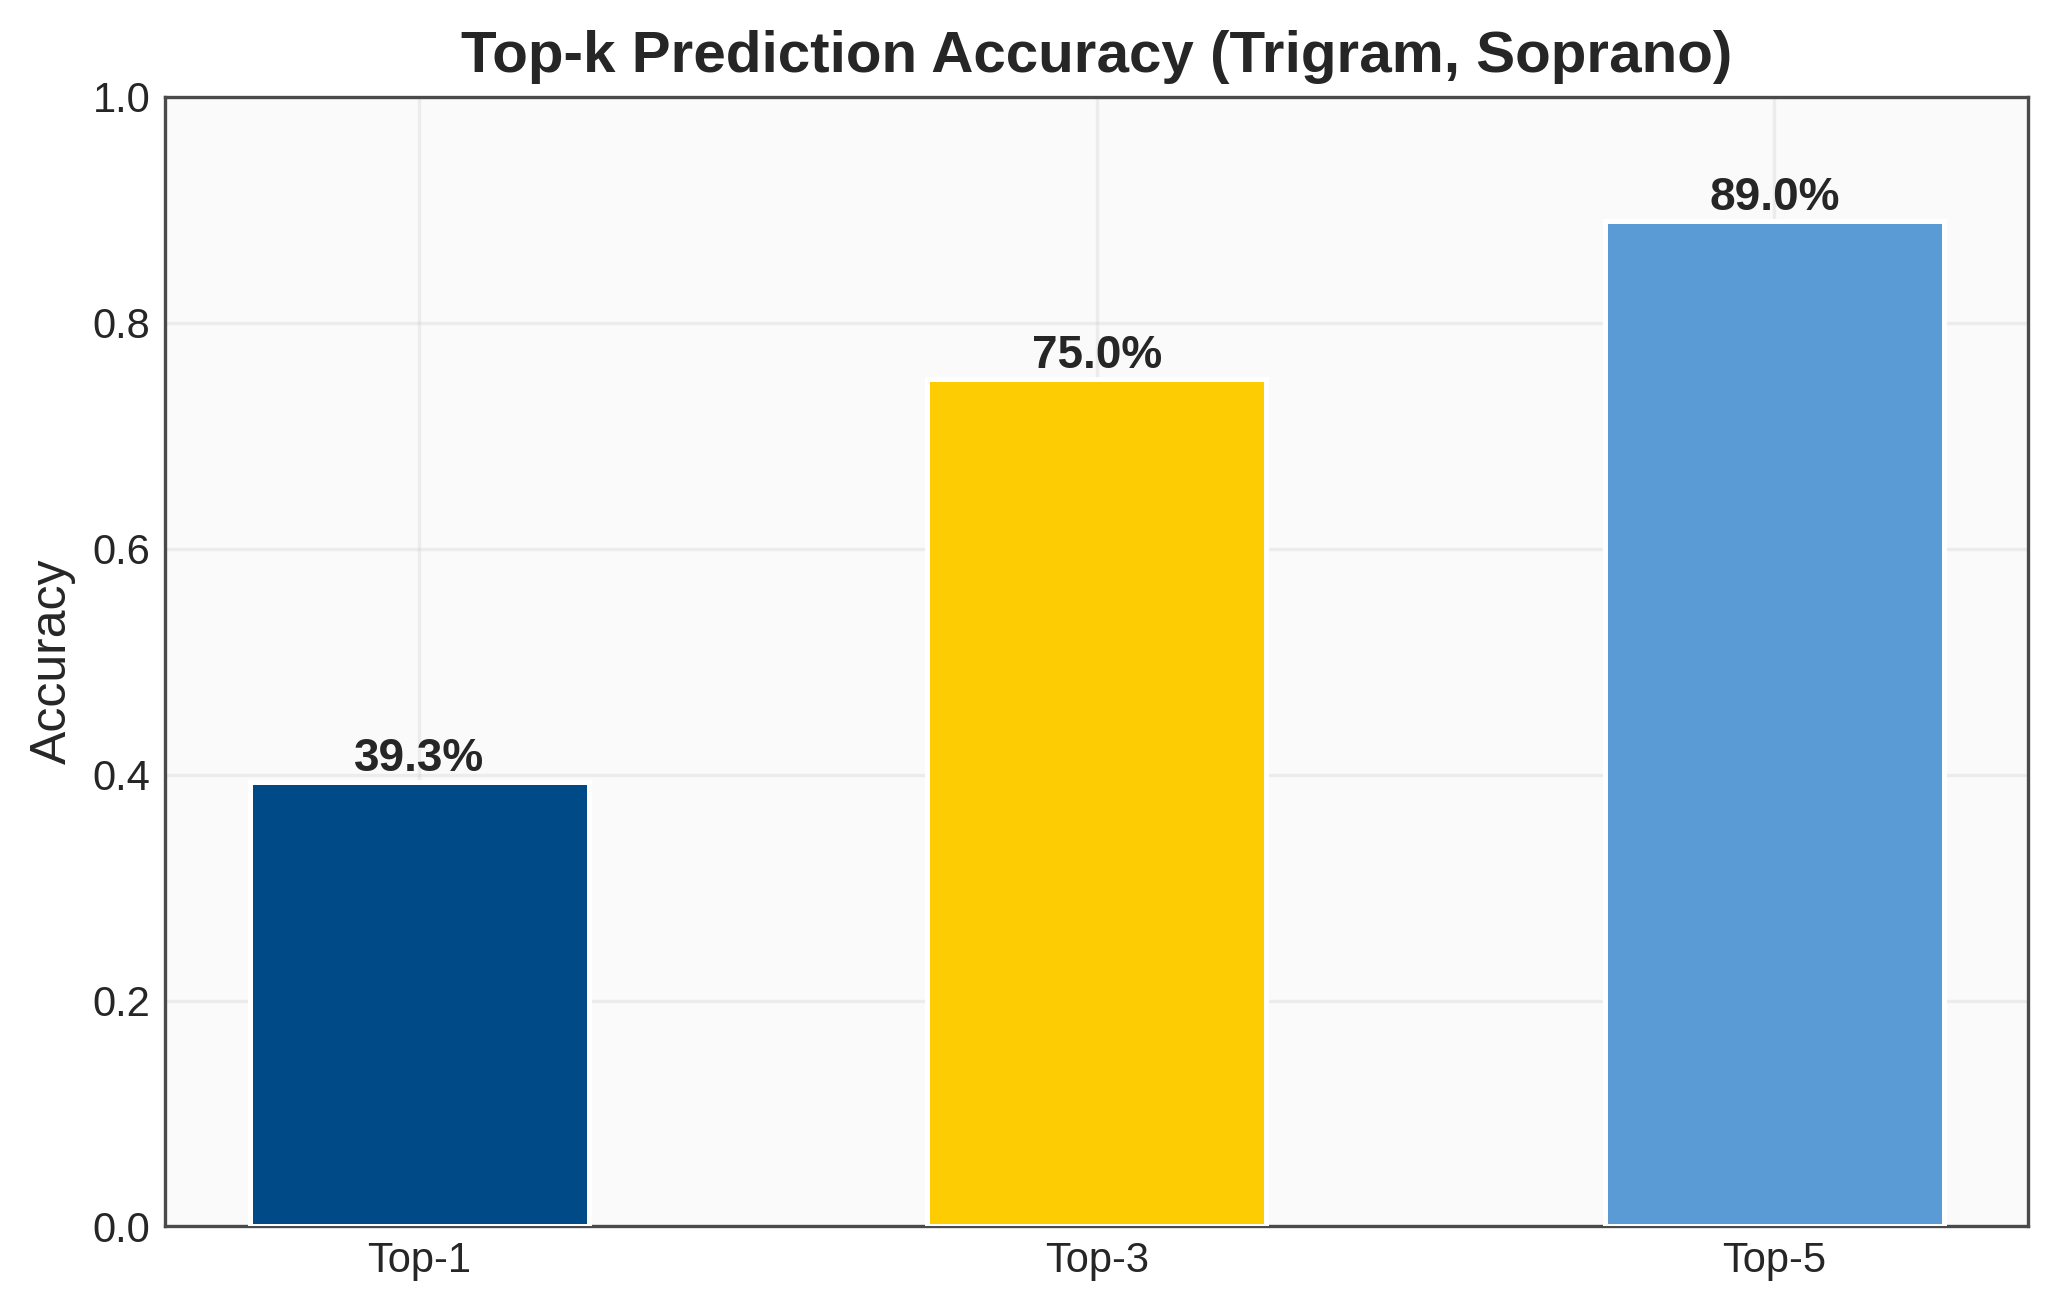

In [79]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ks   = list(topk_accs.keys())
accs_k = [topk_accs[k] for k in ks]
bars = ax.bar([f'Top-{k}' for k in ks], accs_k, color=[BLUE, GOLD, SKY],
              edgecolor='white', linewidth=1.2, width=0.5, zorder=3)
for bar, a in zip(bars, accs_k):
    ax.text(bar.get_x() + bar.get_width()/2, a + 0.01,
            f'{a:.1%}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_title('Top-k Prediction Accuracy (Trigram, Soprano)')
ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.savefig('fig10_topk_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

## 16. Summary

In [80]:
print("=" * 65)
print(f"FULL CORPUS: {len(chorales)} chorales")
print("=" * 65)

print(f"\nExp 1: Accuracy by model order (Soprano):")
for name, res in [('Unigram', results_1), ('Bigram', results_2), ('Trigram', results_3)]:
    print(f"  {name:12s}: acc = {res['accuracy'].mean():.3f}, "
          f"H = {res['cross_entropy'].mean():.3f} bits, ppl = {res['perplexity'].mean():.1f}")

print(f"\nExp 2: Entropy vs. accuracy: r = {r_val:.3f}, p = {p_val:.2e} (null result)")

print(f"\nExp 3: Voice comparison (Trigram):")
for v in part_names:
    r = part_results[v]
    print(f"  {v:10s}: acc = {r['accuracy'].mean():.3f}, "
          f"H = {r['cross_entropy'].mean():.3f} bits (N = {len(r)})")

print(f"\nExp 5: Surprisal by position:")
print(f"  Thirds:  H = {stat_t:.1f}, p = {p_t:.1e}")
print(f"  Fermata: H = {stat_f:.1f}, p = {p_f:.1e}")

print(f"\nExtension A: Interpolated smoothing:")
print(f"  Acc = {results_interp['accuracy'].mean():.3f}, H = {results_interp['cross_entropy'].mean():.3f}")

print(f"\nExtension B: Melody Length vs. Prediction Accuracy:")
print(f"  Pearson r = {r_len:.4f}, p = {p_len:.4e}")

print(f"\nExtension C: Top-k accuracy:")
for k, a in topk_accs.items():
    print(f"  Top-{k}: {a:.1%}")

print(f"\nAll figures saved as PNG (300 dpi) + PDF.")

FULL CORPUS: 412 chorales

Exp 1: Accuracy by model order (Soprano):
  Unigram     : acc = 0.153, H = 3.937 bits, ppl = 20.5
  Bigram      : acc = 0.325, H = 2.727 bits, ppl = 6.9
  Trigram     : acc = 0.397, H = 2.726 bits, ppl = 7.1

Exp 2: Entropy vs. accuracy: r = -0.030, p = 5.45e-01 (null result)

Exp 3: Voice comparison (Trigram):
  Soprano   : acc = 0.397, H = 2.726 bits (N = 411)
  Alto      : acc = 0.337, H = 2.849 bits (N = 411)
  Tenor     : acc = 0.358, H = 3.027 bits (N = 411)
  Bass      : acc = 0.402, H = 3.243 bits (N = 412)

Exp 5: Surprisal by position:
  Thirds:  H = 24.2, p = 5.6e-06
  Fermata: H = 1007.1, p = 2.1e-219

Extension A: Interpolated smoothing:
  Acc = 0.396, H = 2.716

Extension B: Melody Length vs. Prediction Accuracy:
  Pearson r = -0.0488, p = 3.2344e-01

Extension C: Top-k accuracy:
  Top-1: 39.3%
  Top-3: 75.0%
  Top-5: 89.0%

All figures saved as PNG (300 dpi) + PDF.
